# Diseño de un flujo analítico para la clasificación de crisis epilépticas en EEG de superficie: Evaluación sobre el Corpus TUSZ

## 1. Descrición de los pacientes y el dataset

### Librerías utilizadas

In [25]:
import pandas as pd
import pyarrow
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t
from scipy import stats

In [1]:
import nbformat

path = "EDA_EEG_MLR.ipynb"

nb = nbformat.read(path, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "code":
        tags = cell.metadata.get("tags", [])
        if "hide-input" not in tags:
            tags.append("hide-input")
        cell.metadata["tags"] = tags

nbformat.write(nb, path)

In [2]:
import numpy as np

def hampel_test(series, n_sigma=3):

    median = np.median(series)
    mad = np.median(np.abs(series - median))

    threshold = n_sigma * 1.4826 * mad

    difference = np.abs(series - median)

    outliers = difference > threshold

    return outliers

def rosner_test(x, k=5, alpha=0.05):

    x = np.array(x)
    n = len(x)

    R = []
    lambda_vals = []
    temp = x.copy()

    for i in range(1, k+1):

        mean = np.mean(temp)
        std = np.std(temp, ddof=1)

        abs_dev = np.abs(temp - mean)
        max_idx = np.argmax(abs_dev)

        R_i = abs_dev[max_idx] / std
        R.append(R_i)

        p = 1 - alpha/(2*(n-i+1))
        t_val = t.ppf(p, n-i-1)

        lambda_i = ((n-i)*t_val) / np.sqrt((n-i-1 + t_val**2)*(n-i+1))
        lambda_vals.append(lambda_i)

        temp = np.delete(temp, max_idx)

    outliers = []

    for i in reversed(range(k)):
        if R[i] > lambda_vals[i]:
            outliers = list(x[np.argsort(np.abs(x - np.mean(x)))[-i-1:]])
            break

    return outliers

### Carga de datos

Carga del metadata (información detallada sobre cada sesión y paciente en archivos.parquet).

In [3]:
ruta_patients = "C:/Users/USER/Desktop/EDA/02_Metadata/metadata_patients.parquet"
ruta_sessions = "C:/Users/USER/Desktop/EDA/02_Metadata/metadata_sessions.parquet"
metadata_patients = pd.read_parquet(ruta_patients)
metadata_sessions = pd.read_parquet(ruta_sessions)

### 1.1 Exploratorio inicial del metadata

In [9]:
metadata_patients.shape

(675, 8)

Se tienen entonces **675** pacientes con **8** variables demográficas estrucutrales

In [10]:
metadata_sessions.shape

(7364, 11)

Se tienen entonces **7364** sesiones **EEG**

Definición de las variables de **patients.parquet**

In [11]:
data_dict_patients = pd.DataFrame({
    "Variable": metadata_patients.columns,
    "Tipo": metadata_patients.dtypes.values,
    "Descripción": [
        "Identificador numérico anónimo del paciente utilizado internamente en el pipeline.",
        "Identificador alfanumérico original del paciente en el corpus TUSZ.",
        "Split original del dataset definido en el corpus (train/eval/test).",
        "Edad del paciente en años al momento del registro EEG.",
        "Género del paciente (generalmente codificado como 1=male, 2=female).",
        "Número total de sesiones EEG disponibles para ese paciente.",
        "Duración total acumulada de todas las sesiones EEG del paciente en segundos.",
        "Split final del pipeline tras la reorganización para evitar data leakage (train/test)."
    ]
})

data_dict_patients

,Variable,Tipo,Descripción
0,patient_num_id,int64,Identificador numérico anónimo del paciente utilizado internamente en el pipeline.
1,patient_id,object,Identificador alfanumérico original del paciente en el corpus TUSZ.
2,original_split,object,Split original del dataset definido en el corpus (train/eval/test).
3,age,int64,Edad del paciente en años al momento del registro EEG.
4,gender,int64,"Género del paciente (generalmente codificado como 1=male, 2=female)."
5,n_sessions,int64,Número total de sesiones EEG disponibles para ese paciente.
6,total_duration_sec,float64,Duración total acumulada de todas las sesiones EEG del paciente en segundos.
7,split_final,int64,Split final del pipeline tras la reorganización para evitar data leakage (train/test).


Definición de las variables de **patients.parquet**

In [12]:
data_dict_sessions = pd.DataFrame({
    "Variable": metadata_sessions.columns,
    "Tipo": metadata_sessions.dtypes.values,
    "Descripción": [
        "Identificador numérico anónimo del paciente al que pertenece la sesión.",
        "Identificador de la sesión EEG dentro del paciente.",
        "Identificador de partición del registro dentro de la sesión.",
        "Configuración del montaje EEG utilizada en el registro.",
        "Nombre del archivo EDF original que contiene la señal EEG.",
        "Frecuencia de muestreo de la señal EEG en Hz.",
        "Número total de canales EEG registrados en la sesión.",
        "Duración total de la sesión EEG en segundos.",
        "Frecuencia de corte del filtro high-pass aplicado al registro.",
        "Frecuencia de corte del filtro low-pass aplicado al registro.",
        "Fecha en la que se realizó el registro EEG."
    ]
})

data_dict_sessions

,Variable,Tipo,Descripción
0,patient_num_id,int64,Identificador numérico anónimo del paciente al que pertenece la sesión.
1,session_id,object,Identificador de la sesión EEG dentro del paciente.
2,partition_id,object,Identificador de partición del registro dentro de la sesión.
3,config_type,object,Configuración del montaje EEG utilizada en el registro.
4,file_name,object,Nombre del archivo EDF original que contiene la señal EEG.
5,sfreq,float64,Frecuencia de muestreo de la señal EEG en Hz.
6,n_channels,int64,Número total de canales EEG registrados en la sesión.
7,duration_sec,float64,Duración total de la sesión EEG en segundos.
8,highpass,float64,Frecuencia de corte del filtro high-pass aplicado al registro.
9,lowpass,float64,Frecuencia de corte del filtro low-pass aplicado al registro.


Primeros registros de **patients.parquet**

In [13]:
metadata_patients.head()

,patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
0,1,aaaaalpj,train,55,2,4,3015.0,0
1,2,aaaaaipg,train,38,2,3,4600.0,0
2,3,aaaaatvk,eval,28,2,3,9175.0,0
3,4,aaaaapkv,train,89,2,1,1238.0,0
4,5,aaaaalaw,train,28,2,1,1992.0,0


La tabla **metadata_patients** contiene información agregada **a nivel de paciente**. Cada registro corresponde a un paciente único e incluye **variables demográficas** como edad y género, así como **características generales** del registro EEG disponible, como el número total de sesiones y la duración acumulada de dichas sesiones.

Primero registros de  **sessions.parquet**

In [14]:
metadata_sessions.head()

,patient_num_id,session_id,partition_id,config_type,file_name,sfreq,n_channels,duration_sec,highpass,lowpass,date
0,604,s001,t000,01_tcp_ar,aaaaatth_s001_t000.edf,1000.0,30,1289.0,0.0,500.0,2015-01-01
1,3,s001,t000,01_tcp_ar,aaaaatvk_s001_t000.edf,256.0,34,1290.0,0.0,128.0,2015-01-01
2,3,s002,t001,01_tcp_ar,aaaaatvk_s002_t001.edf,256.0,34,301.0,0.0,128.0,2015-01-01
3,3,s002,t002,01_tcp_ar,aaaaatvk_s002_t002.edf,256.0,34,301.0,0.0,128.0,2015-01-01
4,3,s002,t004,01_tcp_ar,aaaaatvk_s002_t004.edf,256.0,34,301.0,0.0,128.0,2015-01-01


La tabla **metadata_sessiones** almacena información detallada **a nivel de sesión EEG**, como parámetros técnicos del registro, duración de la sesión y fecha de adquisición. Esta estructura sugiere una **relación uno a muchos** entre pacientes y sesiones, donde cada paciente puede tener **múltiples** registros EEG asociados.

## 1.2 Demografía de pacientes

```{admonition} Contexto del análisis exploratorio
:class: note

En esta sección se presenta un análisis exploratorio de las características demográficas de los pacientes y de las propiedades generales de los registros EEG disponibles en el dataset.
```

```{admonition} Objetivo de la sección
:class: tip

El objetivo es comprender la distribución de los pacientes, identificar posibles irregularidades en los datos y obtener una primera visión de la estructura del conjunto de datos antes de avanzar hacia análisis más específicos y el desarrollo de modelos de machine learning.
```

### 1.2.1 Edad de los pacientes

Para analizar la **distribución de edad de los pacientes** se construyen un **histograma** y un **diagrama de caja y bigotes**:

Con el fin de tener una mejor comprensión de **posibles outliers**, se aplica al **boxplot** el **identificador de Hampel**, con el fin de visualizar los datos que se sobrepasan su **humbral**:

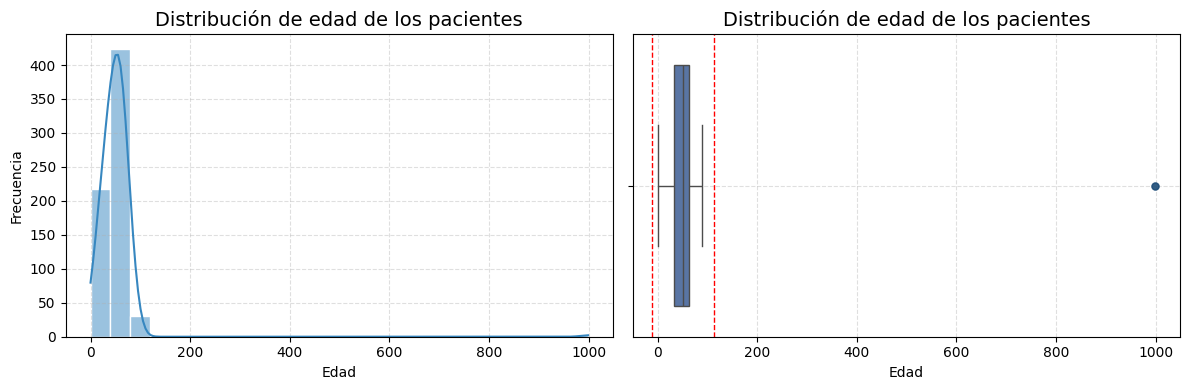

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

age = metadata_patients["age"]

median = age.median()
mad = np.median(np.abs(age - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

sns.histplot(
    age,
    bins=25,
    kde=True,
    color=sns.color_palette("Blues",5)[3],
    edgecolor="white",
    ax=axes[0]
)

axes[0].set_title("Distribución de edad de los pacientes", fontsize=14)
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True, linestyle="--", alpha=0.4)

sns.boxplot(
    x=age,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    ),
    ax=axes[1]
)

axes[1].axvline(lower, color="red", linestyle="--", linewidth=1)
axes[1].axvline(upper, color="red", linestyle="--", linewidth=1)

axes[1].set_title("Distribución de edad de los pacientes", fontsize=14)
axes[1].set_xlabel("Edad")
axes[1].grid(True, linestyle="--", alpha=0.4)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

En el **histograma** se evidencia que la mayoría de los pacientes se concentra en **edades adultas**, aproximadamente entre los **20** y **70** años. No obstante, se observa un valor **extremadamente alto** que distorsiona la escala del gráfico.

El **boxplot** permite confirmar la presencia **valores atípicos**, con un valor extremo cercano a **1000** años, el cual claramente no corresponde a una edad humana posible o alcanzable.

En base a lo anterior, se aplican un **Hampel filter** y un **Rosner's test** con el fin de verificar estadísticamente si en efecto estos registros corresponden a **datos atípicos**.

In [8]:
age_series = metadata_patients["age"]

hampel_outliers = hampel_test(age_series)

metadata_patients.loc[hampel_outliers, ["patient_id", "age"]]

,patient_id,age
255,aaaaapgz,999
414,aaaaacug,999


In [9]:
age_series = metadata_patients["age"]

rosner_outliers = rosner_test(age_series, k=5, alpha=0.05)

metadata_patients[metadata_patients["age"].isin(rosner_outliers)]

,patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
255,256,aaaaapgz,dev,999,1,33,407328.0,0
414,415,aaaaacug,dev,999,2,2,3995.0,0


Los resultados **confirman** la presencia de **2 outliers** en la variable **age**, ambos con un valor de **999** años. Dado que esta edad no corresponde a un valor humano plausible, se **corrobora** la sospecha inicial identificada en el **boxplot**, indicando que estos registros corresponden a probablemente, **errores de digitación**.

Luego, con el fin de obtener una representación más precisa y menos distorsionada de la edad de los pacientes, siguiendo la sugerencia de la **literatura médica**, se utiliza un **filtro de edad** en el que se limita la edad de los pacientes a **120** años, y se genera un nuevo **histograma**.

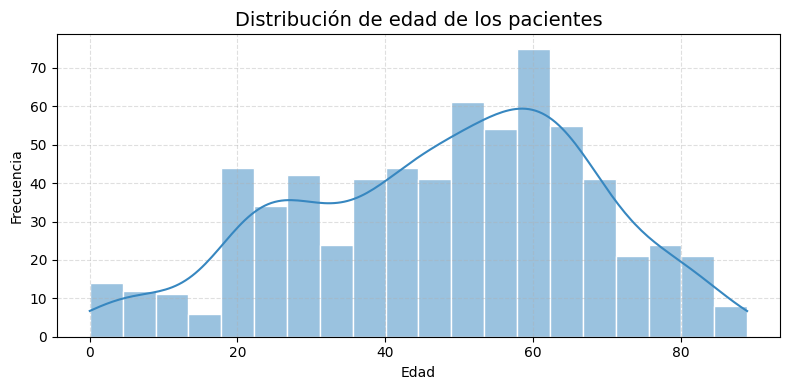

In [15]:
plt.figure(figsize=(8,4))

age_clean = metadata_patients[metadata_patients["age"] < 120]["age"]

sns.histplot(
    age_clean,
    bins=20,
    kde=True,
    color=sns.color_palette("Blues",5)[3],
    edgecolor="white"
)

plt.title("Distribución de edad de los pacientes", fontsize=14)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.grid(True, linestyle="--", alpha=0.4)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

Como era esperado, el **histograma** ya **no presenta** una **distribución distorsionada** y permite corroborar que la mayoría de los pacientes tienen entre **20** y **70** años de edad.



### Pruebas de normalidad


Con el fin de **verificar** la normalidad del **ajuste** de la variable **edad**, se aplican los siguientes **tests** (antes de realizar estas pruebas se **excluyeron** los registros con edad igual a **999** años, previamente identificados como errores de registro).

In [11]:
age_clean = metadata_patients.loc[metadata_patients["age"] < 120, "age"]

```{admonition} Formulación de hipótesis para las pruebas de normalidad
:class: note

Es importante recordar que la **formulación de hipótesis** para estos tres tests es:

- H0: La edad de los pacientes **sigue** una distribución normal.
- H1: La edad de los pacientes **no sigue** una distribución normal.
```

In [20]:
import pandas as pd
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import shapiro, jarque_bera

stat_lillie, p_lillie = lilliefors(age_clean)
stat_shapiro, p_shapiro = shapiro(age_clean)
stat_jb, p_jb = jarque_bera(age_clean)

def estrellas_significancia(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

alpha = 0.05

results = pd.DataFrame({
    "Variable": ["Edad", "Edad", "Edad"],
    "Prueba": ["Lilliefors", "Shapiro-Wilk", "Jarque-Bera"],
    "Estadístico": [stat_lillie, stat_shapiro, stat_jb],
    "Valor p": [p_lillie, p_shapiro, p_jb]
})

results["Estadístico"] = results["Estadístico"].round(4)
results["Valor p"] = results["Valor p"].round(4)

results["Significancia"] = results["Valor p"].apply(estrellas_significancia)

results["Normalidad"] = results["Valor p"].apply(
    lambda p: "Se rechaza normalidad" if p < alpha else "No se rechaza normalidad"
)

results

,Variable,Prueba,Estadístico,Valor p,Significancia,Normalidad
0,Edad,Lilliefors,0.0684,0.001,**,Se rechaza normalidad
1,Edad,Shapiro-Wilk,0.9804,0.000,***,Se rechaza normalidad
2,Edad,Jarque-Bera,19.9380,0.000,***,Se rechaza normalidad


```{admonition} Conclusión de las pruebas de normalidad
:class: important

Los tres tests de normalidad aplicados **(Shapiro–Wilk, Lilliefors y Jarque–Bera**) arrojan **p-values** **significativamente menores** al **nivel de significancia de 0.05**, lo que conduce al **rechazo de la hipótesis nula de normalidad** en todos los casos. 

En particular, el test de **Lilliefors** presenta un nivel de significancia de ** (**p < 0.01**), mientras que los tests de **Shapiro–Wilk y Jarque–Bera** muestran *** (**p < 0.001**), indicando **evidencia estadística muy fuerte** contra la **hipótesis de normalidad**. 

En consecuencia, **se concluye que la distribución de la edad de los pacientes no sigue una distribución normal**, resultado que además es **consistente** con los patrones observados en los gráficos exploratorios previamente presentados.
```

Por último, con el fin de **verificar** que el resultado de las pruebas **no** se vea afectado por la **cantidad de datos** evaluada. Se genera el siguiente **QQ-Plot**:

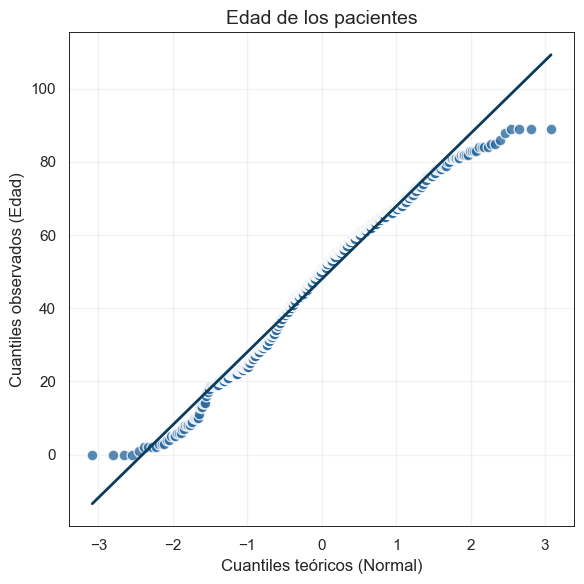

In [26]:
plt.figure(figsize=(6,6))

(osm, osr), (slope, intercept, r) = stats.probplot(age_clean, dist="norm")

plt.scatter(
    osm,
    osr,
    color="#2C6BA0",
    alpha=0.8,
    edgecolor="white",
    s=60
)

plt.plot(
    osm,
    slope*osm + intercept,
    color="#0B3C5D",
    linewidth=2
)

plt.title("Edad de los pacientes", fontsize=14)
plt.xlabel("Cuantiles teóricos (Normal)")
plt.ylabel("Cuantiles observados (Edad)")

plt.grid(alpha=0.25)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

```{admonition} Interpretación del QQ-Plot
:class: tip

Como era esperado y como se **evidenció** a lo largo del desarrollo de esta sección, el **QQ-Plot** demuestra que la variable **edad** **no sigue** una **distribución normal**. 

Esto se debe a que se presentan **desviaciones claras** respecto a la **recta de normalidad**, particularmente en los **cuantiles extremos**; curvatura que indica que los cuantiles observados **no coinciden** con los cuantiles teóricos de una **distribución normal**.
```

### 1.2.2 Género de los pacientes

A continuación, se genera un nuevo **gráfico de barras** para estudiar la **distribución de género en pacientes**:

In [5]:
metadata_patients["gender_label"] = metadata_patients["gender"].map({
    1: "Male",
    2: "Female"
})

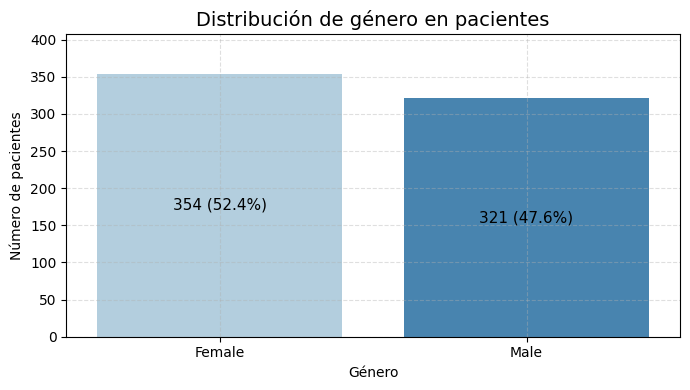

In [7]:
counts = metadata_patients["gender_label"].value_counts()
total = counts.sum()

plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="Blues",
    legend=False
)

plt.title("Distribución de género en pacientes", fontsize=14)
plt.xlabel("Género")
plt.ylabel("Número de pacientes")

for i, v in enumerate(counts.values):

    pct = (v / total) * 100

    ax.text(
        i,
        v / 2,
        f"{v} ({pct:.1f}%)",
        ha="center",
        va="center",
        fontsize=11,
        color="black"
    )

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

```{admonition} Interpretación de la distribución por género
:class: tip

Se observa una distribución **"relativamente"** equilibrada entre ambos grupos, con **354 pacientes femeninos (52.41%)** y **321 pacientes masculinos (47.6%)**. Esta proporción cercana al equilibrio es positiva desde el punto de vista del **modelado**, ya que reduce el riesgo de sesgos relacionados con la representación de género del dataset.
```

### 1.2.3 Sesiones y pacientes

Para observar la **distribución de sesiones EEG por paciente** se presenta el siguiente **boxplot** (incluye identificador de Hampel):

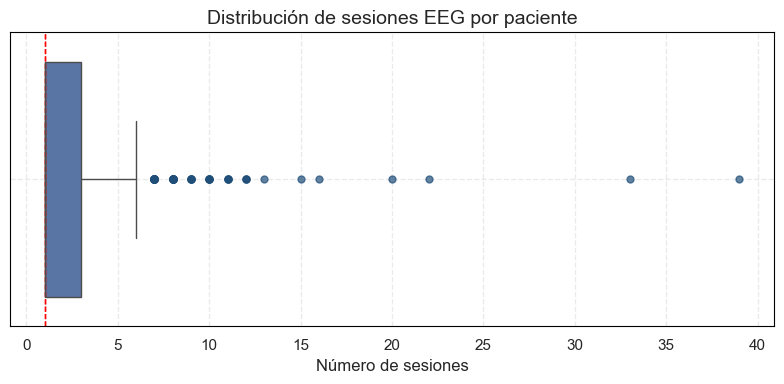

In [26]:
plt.figure(figsize=(8,4))

sessions = metadata_patients["n_sessions"]

median = sessions.median()
mad = np.median(np.abs(sessions - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

ax = sns.boxplot(
    x=sessions,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    )
)

ax.axvline(lower, color="red", linestyle="--", linewidth=1)
ax.axvline(upper, color="red", linestyle="--", linewidth=1)

plt.title("Distribución de sesiones EEG por paciente", fontsize=14)
plt.xlabel("Número de sesiones")

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

```{admonition} Interpretación del boxplot
:class: tip

El **boxplot** muestra una distribución **asimétrica hacia la derecha**. La mayoría de los pacientes tiene entre **1 y 4** sesiones, mientras que un número reducido de pacientes presenta una cantidad considerablemente mayor de sesiones. alcanzando valores cercanos a las **40** sesiones.

Este comportamiento es **esperado** al trabajar con **datos clínicos**, pues, algunos pacientes requieren monitoreo prolongado o múltiples evaluaciones a lo largo del tiempo, y  otros solo necesitan asistir a un pequeño número de sesiones.
```

Para concluir, se genera un último diagrama de **caja y bigotes** con el objetivo de visualizar e interpretar la **distribución del tiempo total de EEG por paciente**:

In [22]:
metadata_patients["total_duration_hours"] = metadata_patients["total_duration_sec"] / 3600

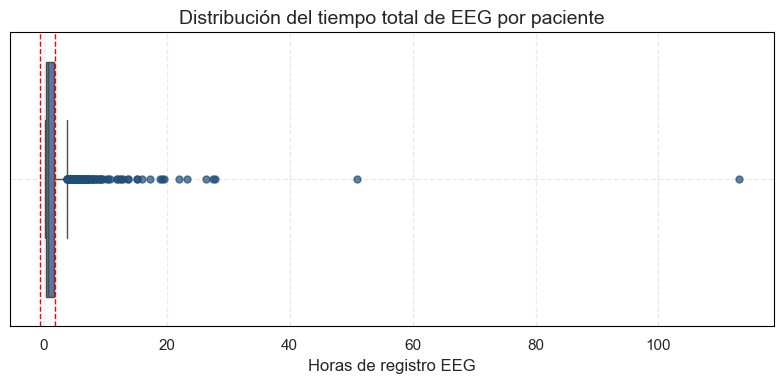

In [27]:
plt.figure(figsize=(8,4))

duration = metadata_patients["total_duration_hours"]

median = duration.median()
mad = np.median(np.abs(duration - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

ax = sns.boxplot(
    x=duration,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    )
)

ax.axvline(lower, color="red", linestyle="--", linewidth=1)
ax.axvline(upper, color="red", linestyle="--", linewidth=1)

plt.title("Distribución del tiempo total de EEG por paciente", fontsize=14)
plt.xlabel("Horas de registro EEG")

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

```{admonition} Interpretación - Tiempo total de EEG por paciente
:class: tip

Nuevamente se observa una distribución **fuertemene sesgada hacia la derecha**, donde la mayoría de los pacientes presentan pocas horas de registro total, y un grupo más redusido, acumula un número considerablemente mayor, superando incluso las **100** horas.

Este patrón también es **coherente con el contexto clínico**, ya que algunos pacientes requieren **monitoreo EEG prolongado**, especialmente en estudios de **epilepsia**.
```

## 2. Features más relevantes

## 2.1 Determinación exploratoria de características relevantes en problemas de clasificación multiclase

In [3]:
import pandas as pd
import pyarrow
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import tqdm


In [6]:
from pathlib import Path
import pandas as pd

PARQUET_PATH = "C:/MachineLearning/data/EDA/04_TUSZ_Features_ML/version=v1_raw_labels"

all_files = list(Path(PARQUET_PATH).rglob("*.parquet"))
print(f"Total archivos: {len(all_files)}")

df_muestra = pd.read_parquet(all_files[0])
print(f"\nTotal columnas: {len(df_muestra.columns)}")
print("\nColumnas:")
print(df_muestra.columns.tolist())

Total archivos: 1641

Total columnas: 1086

Columnas:
['start_time', 'end_time', 'label', 'spatial_ASI', 'spatial_APG', 'spatial_GFP', 'Fp1-F7_A5_rms', 'Fp1-F7_A5_pwr', 'Fp1-F7_A5_ll', 'Fp1-F7_A5_teo', 'Fp1-F7_A5_mean', 'Fp1-F7_A5_std', 'Fp1-F7_A5_skew', 'Fp1-F7_A5_kurt', 'Fp1-F7_A5_ent', 'Fp1-F7_A5_dkatz', 'Fp1-F7_D5_rms', 'Fp1-F7_D5_pwr', 'Fp1-F7_D5_ll', 'Fp1-F7_D5_teo', 'Fp1-F7_D5_mean', 'Fp1-F7_D5_std', 'Fp1-F7_D5_skew', 'Fp1-F7_D5_kurt', 'Fp1-F7_D5_ent', 'Fp1-F7_D5_dkatz', 'Fp1-F7_D4_rms', 'Fp1-F7_D4_pwr', 'Fp1-F7_D4_ll', 'Fp1-F7_D4_teo', 'Fp1-F7_D4_mean', 'Fp1-F7_D4_std', 'Fp1-F7_D4_skew', 'Fp1-F7_D4_kurt', 'Fp1-F7_D4_ent', 'Fp1-F7_D4_dkatz', 'Fp1-F7_D3_rms', 'Fp1-F7_D3_pwr', 'Fp1-F7_D3_ll', 'Fp1-F7_D3_teo', 'Fp1-F7_D3_mean', 'Fp1-F7_D3_std', 'Fp1-F7_D3_skew', 'Fp1-F7_D3_kurt', 'Fp1-F7_D3_ent', 'Fp1-F7_D3_dkatz', 'Fp1-F7_D2_rms', 'Fp1-F7_D2_pwr', 'Fp1-F7_D2_ll', 'Fp1-F7_D2_teo', 'Fp1-F7_D2_mean', 'Fp1-F7_D2_std', 'Fp1-F7_D2_skew', 'Fp1-F7_D2_kurt', 'Fp1-F7_D2_ent', 'Fp1-F7_D2_dka

In [9]:
PARQUET_PATH = "C:/MachineLearning/data/EDA/04_TUSZ_Features_ML/version=v1_raw_labels"

LABEL_MAPPING = {
    'bckg': 'BACKGROUND',
    'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
    'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED',
    'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
}

all_files = list(Path(PARQUET_PATH).rglob("*.parquet"))
print(f"Total archivos: {len(all_files)}")

data_list = []
for f in tqdm.tqdm(all_files, desc="Cargando datos"):
    try:
        df_temp = pd.read_parquet(f)
        df_temp['class'] = df_temp['label'].map(lambda x: LABEL_MAPPING.get(x, 'BACKGROUND'))
        data_list.append(df_temp.sample(n=min(len(df_temp), 30), random_state=42))
    except:
        continue

df = pd.concat(data_list, ignore_index=True)
print(f"\nDataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nDistribución de clases:")
print(df['class'].value_counts())

Total archivos: 1641


Cargando datos: 100%|██████████| 1641/1641 [04:06<00:00,  6.66it/s]



Dataset cargado: 49,169 filas x 1147 columnas

Distribución de clases:
class
BACKGROUND     43239
FOCAL           3827
GENERALIZED     2103
Name: count, dtype: int64


```{admonition} Descripción del conjunto de datos
:class: note

El conjunto de datos analizado comprende un total de 49,169 observaciones y 1,147 variables, en el cual cada observación corresponde a una ventana de señal de electroencefalograma (EEG) y la variable de clase indica el tipo de actividad cerebral registrada.
```

```{admonition} Distribución de clases
:class: warning

Se observa una distribución de clases significativamente desbalanceada: aproximadamente el 88% de las muestras corresponden a actividad normal (BACKGROUND), mientras que un 7.8% representa crisis focales (FOCAL) y un 4.3% corresponde a crisis generalizadas (GENERALIZED). Este tipo de desbalance es típico en conjuntos de datos médicos, donde los eventos patológicos suelen ser menos frecuentes que la actividad cerebral normal.
```

```{admonition} Implicación para el modelado
:class: important

En este contexto, es esencial la incorporación de métricas adicionales más allá de la precisión.
```

In [ ]:

# PANORAMA GENERAL DEL PROBLEMA


# 1. Desbalance de clases
total = len(df)
print("_"*55)
print(" DESBALANCE DE CLASES")
print("_"*55)
for clase, count in df['class'].value_counts().items():
    pct = count/total*100
    barra = "█" * int(pct/2)
    print(f"{clase:<15} {count:>6,} ({pct:>5.1f}%) {barra}")

# 2. Estadísticas básicas de las features por clase
print("\n" + "_"*55)
print(" VARIANZA PROMEDIO POR CLASE")
print(""*55)
META_COLS = ['start_time', 'end_time', 'label', 'class']
X = df.drop(columns=META_COLS, errors='ignore').select_dtypes(include=[np.number]).dropna(axis=1)

var_por_clase = df.groupby('class')[X.columns].var().mean(axis=1)
print(var_por_clase)

# 3. ¿Cuántas features tienen NaNs?
nans = X.isna().sum()
print(f"\n Features con NaNs: {(nans > 0).sum()} de {X.shape[1]}")

# 4. ¿Cuántas features tienen varianza casi cero? (inútiles)
low_var = X.var()[X.var() < 0.001]
print(f" Features con varianza casi cero: {len(low_var)}")

_______________________________________________________
 DESBALANCE DE CLASES
_______________________________________________________
BACKGROUND      43,239 ( 87.9%) ███████████████████████████████████████████
FOCAL            3,827 (  7.8%) ███
GENERALIZED      2,103 (  4.3%) ██

_______________________________________________________
 VARIANZA PROMEDIO POR CLASE
_______________________________________________________
class
BACKGROUND     1702956.875
FOCAL           298963.750
GENERALIZED    1132335.500
dtype: float32

 Features con NaNs: 0 de 963
 Features con varianza casi cero: 21


```{admonition} Distribución de la variable objetivo
:class: note

El análisis de la variable objetivo revela un **marcado desbalance en la distribución de clases** dentro del conjunto de datos. En particular, la clase **BACKGROUND** representa aproximadamente el **87.9%** de las observaciones (43,239 registros), mientras que las clases asociadas a eventos epilépticos, **FOCAL** y **GENERALIZED**, corresponden únicamente al **7.8%** (3,827 registros) y **4.3%**(2,103 registros), respectivamente.

Desde una perspectiva clínica y fisiológica, esta distribución es **coherente** con la naturaleza de los registros electroencefalográficos (EEG). En condiciones normales, la actividad cerebral predominante corresponde a estados no patológicos, mientras que los eventos epilépticos aparecen de forma esporádica y transitoria dentro de las grabaciones. En consecuencia, la mayor parte de las ventanas temporales extraídas de las señales EEG **tienden** a representar actividad cerebral **basal o de fondo**.
```

```{admonition} Implicaciones para el aprendizaje automático
:class: warning

No obstante, desde el punto de vista del aprendizaje automático, este desbalance constituye un desafío importante para los modelos de clasificación, ya que los algoritmos **tienden a favorecer la clase mayoritaria durante el proceso de entrenamiento**. Esto puede conducir a modelos con **alta precisión global** pero con **baja capacidad de detección de eventos epilépticos**, los cuales son precisamente los de mayor relevancia clínica. Por esta razón, resulta fundamental considerar métricas de evaluación más informativas, como **recall, F1-score y matrices de correlación**, así como **estrategias de balanceo** de clases durante el entrenamiento.
```

```{admonition} Análisis de la varianza de las características
:class: note

El análisis de la varianza promedio de las características por clase muestra **diferencias notables** entre los distintos tipos de actividad cerebral. En particular, la clase **BACKGROUND** presenta la **mayor varianza promedio (≈ 1,702,956)**, seguida por la clase **GENERALIZED (≈ 1,132,335)**, mientras que la clase **FOCAL** exhibe una varianza **considerablemente menor (≈ 298,964)**.

Desde la perspectiva del procesamiento de señales EEG, estas diferencias pueden interpretarse en términos de la heterogeneidad de los patrones de actividad neuronal asociados a cada tipo de evento.
```

```{admonition} Interpretación fisiológica
:class: tip

La mayor varianza observada en la clase **BACKGROUND** sugiere que la actividad cerebral normal presenta una alta diversidad de patrones dinámicos, lo cual es consistente con la naturaleza compleja del funcionamiento cerebral en estados fisiológicos. Durante la actividad normal, el EEG refleja múltiples procesos cognitivos y fisiológicos simultáneos, tales como estados de alerta, descanso, procesamiento sensorial y actividad espontánea de distintas regiones corticales. Esta diversidad funcional se traduce en una mayor dispersión estadística de las características extraídas de las señales.

Por el contrario, las crisis **FOCAL** muestran una varianza significativamente menor, lo que sugiere la presencia de patrones más homogéneos y estructurados en las características extraídas. Esto puede explicarse por el hecho de que las crisis focales se originan en regiones específicas del cerebro, generando patrones electrofisiológicos relativamente consistentes dentro de las señales registradas.

En el caso de las crisis **GENERALIZED**, la varianza intermedia observada podría reflejar la naturaleza más distribuida de este tipo de eventos epilépticos, en los cuales la actividad anómala se propaga a través de amplias regiones corticales. Como resultado, las características extraídas de estas señales pueden presentar mayor variabilidad que en las crisis focales, aunque todavía mantienen cierta estructura distintiva frente a la actividad cerebral normal.
```

```{admonition} Implicación para el modelado
:class: important

Estas diferencias en la dispersión de las características entre clases pueden resultar beneficiosas para los modelos de aprendizaje automático, ya que sugieren la existencia de **patrones discriminativos** potencialmente explotables durante el **proceso de clasificación.**

Estos resultados constituyen una base importante para las siguientes etapas del proyecto, particularmente en lo relacionado con **preprocesamiento de datos, selección de características y diseño de modelos de clasificación** para la detección automática de eventos epilépticos.
```

## 2.2 Relevancia en las features

## Características más relevantes

```{admonition} Selección de características
:class: important

El análisis presentado corresponde a un proceso de **selección de características (feature selection)** realizado mediante una combinación de **Mutual Information (MI)**, el algoritmo **Minimum Redundancy Maximum Relevance (mRMR)** y el análisis de varianza. El objetivo de esta etapa es identificar aquellas variables que contienen mayor información relevante para la clasificación de los distintos tipos de actividad cerebral registrados en las señales EEG, minimizando al mismo tiempo la redundancia entre características.

La tabla muestra las **15 características más informativas del conjunto de datos**, ordenadas según el ranking producido por el algoritmo mRMR. Cada registro incluye la posición de la característica en el ranking, el nombre de la variable, el valor de **Mutual Information** respecto a la variable objetivo y la **varianza** observada en el conjunto de datos.

Este tipo de selección es particularmente importante en problemas de análisis de EEG, ya que estos datasets suelen presentar **alta dimensionalidad**, es decir, un número muy grande de variables en comparación con el número de observaciones. En este contexto, la selección de características permite reducir la dimensionalidad conservando únicamente aquellas variables que aportan mayor capacidad discriminativa para el modelo de clasificación.
```

---

## Información Mutua

```{admonition} Definición de Mutual Information
:class: note

La **Mutual Information (MI)** mide la cantidad de información compartida entre una característica $X$ y la variable objetivo $Y$. Matemáticamente, esta medida puede expresarse como:

$$
MI(X,Y) = H(X) + H(Y) - H(X,Y)
$$

donde $H(\cdot)$ representa la **entropía de Shannon**, que cuantifica la incertidumbre asociada a una variable aleatoria.
```

```{admonition} Interpretación de la medida
:class: tip

En términos intuitivos, la información mutua mide **cuánto se reduce la incertidumbre sobre la variable objetivo al conocer el valor de una característica**. Por lo tanto, valores más altos de $MI(X,Y)$ indican que la variable contiene mayor información relevante para distinguir entre las diferentes clases del problema.
```

```{admonition} Observación sobre los valores de MI
:class: warning

En el ranking presentado, los valores de información mutua se encuentran aproximadamente en el rango:

$$
MI \in [0.009, 0.021]
$$

Aunque estos valores pueden parecer pequeños, este comportamiento es esperable en contextos de **alta dimensionalidad** como el análisis de señales EEG, donde cada característica individual aporta únicamente una fracción de la información total necesaria para la clasificación.

La característica mejor posicionada en el ranking es **P4-O2_A5_ll**, con un valor de $MI = 0.0215$, lo que sugiere que esta variable proporciona la mayor cantidad de información individual para discriminar entre los distintos tipos de actividad cerebral presentes en el dataset.
```

---

## Varianza de las Características

```{admonition} Interpretación de la varianza
:class: note

La columna de **varianza** refleja el grado de dispersión de los valores de cada característica dentro del conjunto de datos. Se observa que las features presentan niveles de varianza muy diferentes entre sí, con valores que van desde magnitudes pequeñas hasta valores considerablemente elevados.
```

```{admonition} Diferencias de escala en las features
:class: tip

Esta diferencia se debe a que cada característica captura **propiedades distintas de la señal EEG** y, por lo tanto, se encuentra en **escalas numéricas diferentes**. Por ejemplo:

- métricas estadísticas como **skewness (asimetría)** suelen tomar valores relativamente pequeños
- medidas relacionadas con **energía o complejidad de la señal** pueden presentar valores significativamente mayores.
```

```{admonition} Implicación para el preprocesamiento
:class: warning

La presencia de diferentes escalas sugiere que, durante las etapas posteriores del análisis, puede ser necesario aplicar **técnicas de normalización o estandarización**, con el fin de evitar que ciertas características dominen el proceso de aprendizaje únicamente debido a su escala numérica.
```

---

## Estructura de las características EEG

```{admonition} Estructura general de una feature EEG
:class: important

Un aspecto fundamental para comprender la tabla consiste en interpretar correctamente la estructura de los nombres de las características. Cada **feature** contiene información sobre tres componentes principales de la señal EEG:

1. La región cerebral analizada  
2. El nivel de descomposición de la señal  
3. El tipo de característica estadística extraída  

En términos generales, una característica puede representarse como:

$$
\text{Electrodo}_1 - \text{Electrodo}_2 \; \_ \; \text{NivelWavelet} \; \_ \; \text{Característica}
$$
```

Por ejemplo, la feature:

**Fp2-F4_D3_dkatz**

puede interpretarse de la siguiente manera.

---

### Derivación EEG

```{admonition} Derivación entre electrodos
:class: note

**Fp2-F4**

Representa la derivación entre los electrodos **Fp2 y F4** del sistema internacional **10–20** utilizado en electroencefalografía.

Esta derivación mide la **diferencia de potencial eléctrico entre dos regiones de la corteza frontal**, permitiendo capturar variaciones espaciales de la actividad cerebral.
```

---

### Nivel de descomposición wavelet

```{admonition} Nivel de detalle wavelet
:class: tip

**D3**

Corresponde al **tercer nivel de detalle de la descomposición wavelet** de la señal.

Las transformadas wavelet permiten descomponer el EEG en diferentes **bandas de frecuencia**, separando componentes de alta y baja frecuencia. En general:

- **D (Detail)** representa componentes de alta frecuencia  
- **A (Approximation)** representa componentes de baja frecuencia  

Esto permite analizar la señal en distintas escalas temporales.
```

---

### Tipo de característica extraída

```{admonition} Métrica de complejidad
:class: note

**dkatz**

Corresponde a la **dimensión fractal de Katz**, una medida utilizada para cuantificar la **complejidad geométrica de una señal temporal**.

La dimensión fractal permite caracterizar el grado de irregularidad o complejidad del EEG, lo cual resulta especialmente útil para detectar cambios en la dinámica cerebral asociados a eventos epilépticos.
```

---

## Tipos de características presentes en el ranking

```{admonition} Tipos de métricas extraídas del EEG
:class: important

Las features seleccionadas incluyen diversas métricas que capturan diferentes propiedades de la señal EEG:

- **pwr** → potencia de la señal en una banda de frecuencia  
- **kurt** → curtosis de la distribución de amplitudes  
- **skew** → asimetría de la distribución  
- **ll (line length)** → medida de complejidad temporal de la señal  
- **dkatz** → dimensión fractal de Katz  
- **teo** → operador de energía de Teager  
```

Estas métricas permiten describir propiedades relacionadas con:

- energía de la señal
- estructura estadística
- complejidad temporal
- comportamiento no lineal

---

```{admonition} Interpretación neurofisiológica
:class: tip

La presencia de características provenientes de diferentes derivaciones EEG, incluyendo regiones **frontales, temporales y parieto–occipitales**, sugiere que la discriminación entre clases se basa en **patrones espaciales distribuidos en múltiples regiones del cerebro**.

Esto es consistente con la literatura sobre epilepsia, donde las crisis pueden originarse o propagarse a través de distintas áreas corticales.

Asimismo, la aparición de características relacionadas con **energía, complejidad fractal y propiedades estadísticas de la señal** indica que las crisis epilépticas producen **cambios estructurales en la dinámica del EEG**.

Estos cambios pueden manifestarse como:

- variaciones en la energía de la señal  
- alteraciones en la complejidad temporal  
- modificaciones en la distribución estadística de las amplitudes  
```

```{admonition} Conclusión de la selección de características
:class: important

En conjunto, los resultados del ranking sugieren que la discriminación entre clases se basa en una **combinación de información espacial, espectral y estadística de las señales EEG**.

La selección de estas características mediante el método **mRMR** permite reducir la dimensionalidad del problema manteniendo las variables más informativas y menos redundantes, lo cual puede contribuir a mejorar el rendimiento de los modelos de clasificación en etapas posteriores del análisis.
```

A continuación, se tabuló la descripción de las features con su respectiva descripción y contextualización.

## 2.3 Selección de variables y Análisis Exploratorio

In [27]:
top15_info = {
    'P4-O2_A5_ll':      'Longitud de línea del canal parieto-occipital derecho en banda de aproximación (A5). Mide cambios de amplitud en frecuencias bajas.',
    'Fp2-F4_D3_dkatz':  'Dimensión fractal de Katz del canal fronto-polar derecho en banda D3. Cuantifica la complejidad no lineal de la señal.',
    'C3-P3_D1_skew':    'Asimetría estadística del canal centro-parietal izquierdo en banda D1. Indica asimetría en la distribución de la señal de alta frecuencia.',
    'Fp2-F8_A5_dkatz':  'Dimensión fractal de Katz del canal fronto-temporal derecho en banda de aproximación. Mide irregularidad en frecuencias bajas.',
    'T4-T6_D5_dkatz':   'Dimensión fractal de Katz del canal temporal derecho en banda D5. Captura complejidad en frecuencias delta-theta.',
    'P3-O1_D1_skew':    'Asimetría del canal parieto-occipital izquierdo en banda D1. Refleja asimetría en componentes de alta frecuencia.',
    'Fp1-F7_D1_dkatz':  'Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D1. Mide complejidad en frecuencias gamma.',
    'T3-T5_D2_dkatz':   'Dimensión fractal de Katz del canal temporal izquierdo en banda D2. Captura irregularidad en frecuencias beta alta.',
    'T3-T5_D4_pwr':     'Potencia del canal temporal izquierdo en banda D4. Mide la energía de la señal en frecuencias theta.',
    'F7-T3_D5_dkatz':   'Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D5. Mide complejidad en frecuencias delta.',
    'Fp2-F4_D5_dkatz':  'Dimensión fractal de Katz del canal fronto-polar derecho en banda D5. Captura complejidad en frecuencias muy bajas.',
    'Fp1-F3_D3_dkatz':  'Dimensión fractal de Katz del canal fronto-polar izquierdo en banda D3. Mide irregularidad en frecuencias alpha.',
    'Fp1-F7_D3_dkatz':  'Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D3. Captura complejidad en frecuencias alpha.',
    'Fp1-F7_D4_dkatz':  'Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D4. Mide complejidad en frecuencias theta.',
    'F8-T4_D5_dkatz':   'Dimensión fractal de Katz del canal fronto-temporal derecho en banda D5. Captura irregularidad en frecuencias delta.'
}

data_dict_top15 = pd.DataFrame({
    'mRMR_Rank': range(1, 16),
    'Feature': list(top15_info.keys()),
    'Tipo': ['float32'] * 15,
    'Descripción': list(top15_info.values())
})

data_dict_top15

,mRMR_Rank,Feature,Tipo,Descripción
0,1,P4-O2_A5_ll,float32,Longitud de línea del canal parieto-occipital derecho en banda de aproximación (A5). Mide cambios de amplitud en frecuencias bajas.
1,2,Fp2-F4_D3_dkatz,float32,Dimensión fractal de Katz del canal fronto-polar derecho en banda D3. Cuantifica la complejidad no lineal de la señal.
2,3,C3-P3_D1_skew,float32,Asimetría estadística del canal centro-parietal izquierdo en banda D1. Indica asimetría en la distribución de la señal de alta frecuencia.
3,4,Fp2-F8_A5_dkatz,float32,Dimensión fractal de Katz del canal fronto-temporal derecho en banda de aproximación. Mide irregularidad en frecuencias bajas.
4,5,T4-T6_D5_dkatz,float32,Dimensión fractal de Katz del canal temporal derecho en banda D5. Captura complejidad en frecuencias delta-theta.
5,6,P3-O1_D1_skew,float32,Asimetría del canal parieto-occipital izquierdo en banda D1. Refleja asimetría en componentes de alta frecuencia.
6,7,Fp1-F7_D1_dkatz,float32,Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D1. Mide complejidad en frecuencias gamma.
7,8,T3-T5_D2_dkatz,float32,Dimensión fractal de Katz del canal temporal izquierdo en banda D2. Captura irregularidad en frecuencias beta alta.
8,9,T3-T5_D4_pwr,float32,Potencia del canal temporal izquierdo en banda D4. Mide la energía de la señal en frecuencias theta.
9,10,F7-T3_D5_dkatz,float32,Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D5. Mide complejidad en frecuencias delta.


## Interpretación de las características seleccionadas

El análisis de las 15 características permite identificar varios patrones relevantes en la información extraída de las señales EEG. En particular, se observan regularidades en términos de complejidad de la señal, localización espacial de los electrodos y distribución espectral de las frecuencias analizadas.

---

### Complejidad de la señal EEG

```{admonition} Dimensión fractal de Katz (dkatz)
:class: note

**Dimensión fractal de Katz (dkatz).**  
Se observa un claro predominio de características basadas en la dimensión fractal de Katz (dkatz), la cual aparece en la mayoría de las features seleccionadas. Esta medida cuantifica la complejidad geométrica o irregularidad temporal de una señal. En este contexto, se sugiere que la complejidad no lineal de la señal EEG constituye una propiedad altamente informativa para distinguir entre diferentes tipos de actividad cerebral. Este resultado sugiere que los patrones asociados a eventos epilépticos pueden manifestarse como cambios en la estructura temporal o en la irregularidad de la señal.
```

---

### Localización espacial de las señales

**Derivaciones frontales y temporales.**  
Muchas de las características más relevantes provienen de derivaciones como **Fp1–F7, Fp2–F8, T3–T5, F7–T3**, entre otras. Estas corresponden principalmente a regiones **frontales, fronto-temporales y temporales** del cerebro. En este caso, se sugiere que estas regiones están asociadas con áreas corticales donde frecuentemente se originan o se propagan crisis epilépticas, particularmente en epilepsias del lóbulo temporal. La recurrencia de estas derivaciones dentro de las características mejor posicionadas sugiere que la información espacial proveniente de estas zonas cerebrales podría ser altamente discriminativa para el problema de clasificación.

---

### Información espectral de la señal

```{admonition} Múltiples niveles wavelet
:class: tip

**Múltiples niveles wavelet (D1–D5, A5).**  
Las features seleccionadas aparecen distribuidas en distintos niveles de descomposición wavelet, incluyendo **D1, D2, D3, D4, D5 y A5**, lo que indica que la información relevante para la clasificación no se concentra en una sola banda de frecuencia. En este sentido, Sharma et al. (2020) demuestran que *“DWT decomposes EEG signals into time-frequency components... detail coefficients (DCs) D1–D5... superior for epileptic seizure detection”* [web:116]. Este resultado confirma que la información relevante para la detección de crisis epilépticas puede encontrarse distribuida a lo largo de múltiples componentes espectrales de la señal EEG.
```

---

### Métricas estadísticas y energéticas

**Skewness, potencia (pwr) y line length (ll).**  
Además de las medidas de complejidad fractal, también aparecen otras métricas como **skewness (skew)**, **potencia de la señal (pwr)** y **line length (ll)**. Estas variables capturan diferentes propiedades de la señal: la skewness describe la asimetría de la distribución de amplitudes, la potencia mide la energía de la señal dentro de una determinada banda de frecuencia, mientras que la longitud de línea cuantifica la variabilidad o actividad temporal de la señal. En este caso, se sugiere que estas características aportan información **estadística, energética y temporal complementaria**, lo cual puede contribuir a mejorar la capacidad discriminativa del conjunto de features.

---

```{admonition} Síntesis de los resultados
:class: important

En conjunto, estos resultados sugieren que la discriminación entre las distintas clases de actividad cerebral se basa en una combinación de **información espacial (derivaciones EEG), espectral (bandas de frecuencia wavelet) y dinámica (complejidad y propiedades estadísticas de la señal)**. Esta combinación de características permite capturar distintos aspectos del comportamiento del EEG, lo que potencialmente facilita la identificación de patrones asociados a eventos epilépticos dentro del conjunto de datos.
```

In [38]:
META_COLS = ['start_time', 'end_time', 'label', 'class']
X = df.drop(columns=META_COLS, errors='ignore').select_dtypes(include=[np.number])

resultados = []

for feat in df_tabla_top['Feature']:
    serie = X[feat].dropna()
    
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((serie < lower) | (serie > upper)).sum()
    pct_outliers = n_outliers / len(serie) * 100
    
    resultados.append({
        'Feature':    feat,
        'Media':      round(serie.mean(), 4),
        'Mediana':    round(serie.median(), 4),
        'Std':        round(serie.std(), 4),
        'Min':        round(serie.min(), 4),
        'Max':        round(serie.max(), 4),
        'Q1':         round(Q1, 4),
        'Q3':         round(Q3, 4),
        'IQR':        round(IQR, 4),
        'Skewness':   round(stats.skew(serie), 4),
        'Kurtosis':   round(stats.kurtosis(serie), 4),
        'N_Outliers': int(n_outliers),
        '%_Outliers': round(pct_outliers, 2)
    })

df_centralidad = pd.DataFrame(resultados)

print("_"*150)
print(" Tabla de Centralidad de las Top 15 Features ")
print("_"*150)
print(df_centralidad.to_string(index=False))
print("_"*150)

______________________________________________________________________________________________________________________________________________________
 Tabla de Centralidad de las Top 15 Features 
______________________________________________________________________________________________________________________________________________________
        Feature   Media  Mediana         Std            Min          Max      Q1     Q3     IQR  Skewness   Kurtosis  N_Outliers  %_Outliers
    P4-O2_A5_ll  2.6781   2.6230    0.868700       0.000000    24.459299  2.1581 3.1189  0.9608    2.4945    31.3533        1126        2.29
  P4-O2_D1_kurt  2.2677   0.2227   12.062100      -1.476300   255.702499 -0.0699 0.9077  0.9777   14.4640   262.0324        6832       13.89
  Fp1-F7_D4_pwr  0.8704   0.5047    6.858300       0.000000   858.792419  0.2443 0.9693  0.7249   96.2560 10478.9745        3004        6.11
 T4-T6_D5_dkatz  4.2791   3.1825   75.796303   -2283.902588 14344.255859  2.6918 4.0044 

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_call'

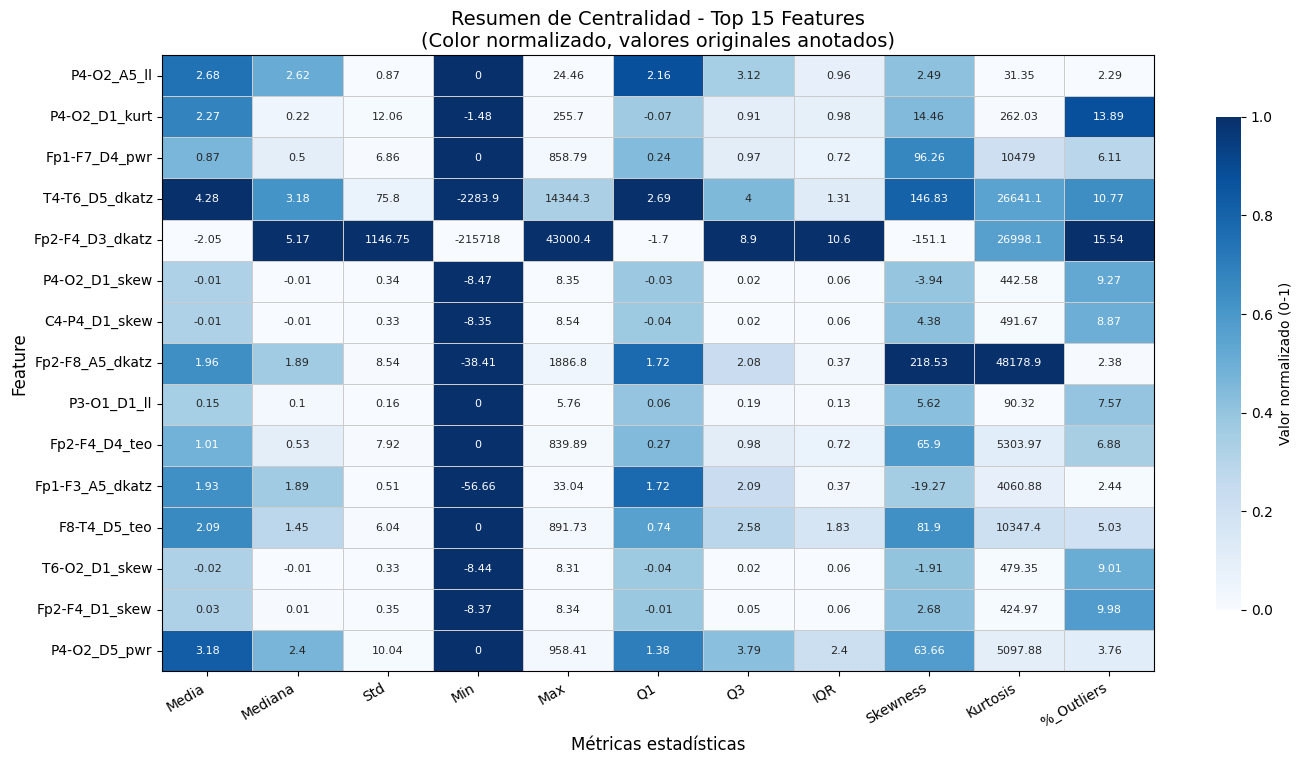

In [40]:
from sklearn.preprocessing import MinMaxScaler

cols_numericas = ['Media', 'Mediana', 'Std', 'Min', 'Max', 'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', '%_Outliers']

df_heat = df_centralidad[cols_numericas].copy()
df_heat.index = df_centralidad['Feature']

scaler = MinMaxScaler()
df_heat_norm = pd.DataFrame(
    scaler.fit_transform(df_heat),
    index=df_heat.index,
    columns=df_heat.columns
)

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    df_heat_norm,
    annot=df_heat.round(2),
    fmt='g',
    cmap=sns.color_palette("Blues", as_cmap=True),
    linewidths=0.5,
    linecolor='#cccccc',
    cbar_kws={'label': 'Valor normalizado (0-1)', 'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title("Resumen de Centralidad - Top 15 Features\n(Color normalizado, valores originales anotados)",
             fontsize=14)
ax.set_xlabel("Métricas estadísticas", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.grid(False)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_call()
plt.show()

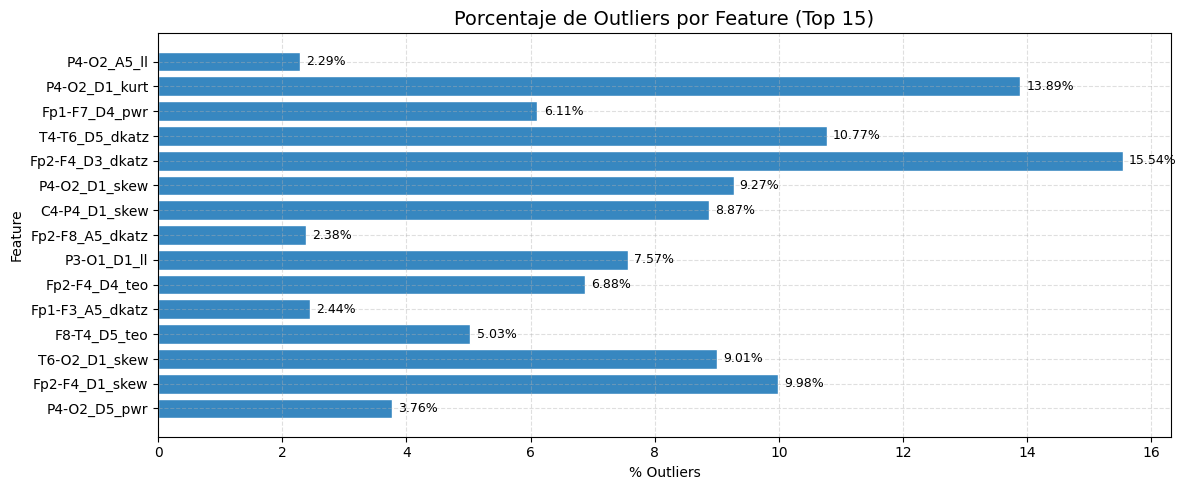

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

colores = [sns.color_palette("Blues", 5)[3]] * 15
bars = ax.barh(
    df_centralidad['Feature'][::-1],
    df_centralidad['%_Outliers'][::-1],
    color=colores,
    edgecolor='white'
)

for bar, val in zip(bars, df_centralidad['%_Outliers'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

ax.set_title("Porcentaje de Outliers por Feature (Top 15)", fontsize=14)
ax.set_xlabel("% Outliers")
ax.set_ylabel("Feature")
ax.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

### Valores atípicos (Outliers)

```{admonition} Identificación de valores atípicos
:class: note

Uno de los aspectos más relevantes observados en la Tabla de Centralidad es la presencia de valores atípicos (*outliers*) en varias de las características seleccionadas. Los outliers fueron identificados utilizando el criterio del rango intercuartílico (IQR), el cual considera como valores atípicos aquellos que se encuentran por debajo de \(Q1 - 1.5 \times IQR\) o por encima de \(Q3 + 1.5 \times IQR\).
```

---

### Distribución de outliers en las features

La gráfica muestra el porcentaje de valores atípicos presentes en cada una de las **15 características más relevantes**.

En la gráfica se observa que algunas características presentan porcentajes considerables de outliers. Por ejemplo, la característica *Fp2-F4_D3_dkatz* presenta aproximadamente un 15.54% de valores atípicos, mientras que *P4-O2_D1_kurt* presenta cerca del 13.89%. Asimismo, otras características como *T4-T6_D5_dkatz* y varias métricas de *skewness* también muestran proporciones relevantes de valores extremos.

---

### Interpretación estadística

Desde una perspectiva estadística, la presencia de un número elevado de outliers está asociada con distribuciones altamente asimétricas y con curtosis elevada, lo cual también se refleja en los valores de *skewness* y *kurtosis* reportados en la tabla. Este comportamiento indica que la distribución de varias características presenta colas pesadas y eventos extremos poco frecuentes pero de gran magnitud.

---

### Interpretación neurofisiológica

```{admonition} Significado fisiológico de los outliers
:class: tip

En el contexto del análisis de señales EEG, estos valores extremos no necesariamente corresponden a ruido o errores de medición. Por el contrario, es posible que reflejen eventos fisiológicos relevantes, tales como descargas epileptiformes, picos de alta amplitud o cambios abruptos en la dinámica neuronal. Las crisis epilépticas y los eventos preictales suelen caracterizarse por transitorios pronunciados en la señal EEG, los cuales pueden manifestarse estadísticamente como valores atípicos dentro de las características extraídas.
```

Adicionalmente, la presencia de outliers puede indicar que ciertas características son altamente sensibles a cambios en la actividad cerebral, lo cual puede resultar beneficioso para tareas de clasificación. Se sugiere que estas observaciones refuerzan la relevancia de las características seleccionadas, ya que capturan eventos poco frecuentes pero potencialmente discriminativos entre estados normales y epilépticos.

---

```{admonition} Conclusión
:class: important

En consecuencia, en lugar de eliminar completamente estos valores extremos, se sugiere que su presencia sea interpretada como una manifestación de la naturaleza dinámica y no estacionaria de las señales EEG, así como de la posible aparición de eventos neurofisiológicos relevantes dentro de los registros analizados.
```

```{admonition} Tabla de centralidad
:class: note

La Tabla de Centralidad presenta un análisis estadístico descriptivo de las quince características más relevantes identificadas por el modelo de clasificación. Cada fila corresponde a una característica derivada de la señal EEG, definida por una combinación de derivación electroencefalográfica, nivel de descomposición wavelet y métrica de extracción de características.
```

La nomenclatura utilizada en la columna **Feature** sigue la estructura:

$$
\text{Derivación}_{\text{NivelWavelet}}^{\text{Métrica}}
$$

Por ejemplo,

$$
\text{P4-O2\_A5\_ll}
$$

indica que la característica fue extraída de la derivación P4–O2, utilizando el coeficiente de aproximación \(A5\) de la descomposición wavelet discreta (DWT), y corresponde a la métrica *line length*.

---

### Métricas estadísticas reportadas

Las columnas estadísticas permiten caracterizar la distribución de cada característica dentro del conjunto de datos:

- **Media y Mediana**: describen la tendencia central de la distribución. Diferencias significativas entre ambos valores sugieren distribuciones asimétricas.
- **Std**: mide la variabilidad de los valores alrededor de la media.
- **Min y Max**: representan los valores extremos observados.
- **Q1, Q3 e IQR**: describen la dispersión robusta de los datos mediante el rango intercuartílico.
- **Skewness**: cuantifica el grado de asimetría de la distribución.
- **Kurtosis**: evalúa la presencia de colas pesadas o valores extremos.
- **N_Outliers y %_Outliers**: indican la cantidad y proporción de valores atípicos detectados mediante el criterio del rango intercuartílico.

Los resultados evidencian que varias características presentan valores elevados de *skewness* y *kurtosis*, lo cual indica distribuciones altamente asimétricas con colas pesadas. Se sugiere que este comportamiento refleja la naturaleza no estacionaria y altamente variable de las señales EEG, particularmente en presencia de eventos epilépticos, donde pueden aparecer transitorios de gran amplitud y cambios abruptos en la dinámica de la señal.

Asimismo, la presencia de un porcentaje considerable de valores atípicos en varias características sugiere que ciertos segmentos del EEG contienen patrones extremos o transitorios que podrían corresponder a descargas epileptiformes o actividad neuronal anómala. Se sugiere que estos valores extremos contienen información discriminativa relevante que puede ser aprovechada por el modelo de clasificación.

---

## Características seleccionadas

### Complejidad de la señal

```{admonition} Dimensión fractal de Katz (dkatz)
:class: tip
```

**Dimensión fractal de Katz (dkatz)**.

Esta métrica captura la complejidad geométrica y la irregularidad de la señal EEG. La dimensión fractal de Katz cuantifica la relación entre la longitud total de la trayectoria de la señal y su diámetro, proporcionando una estimación de la complejidad de la dinámica temporal. En señales EEG asociadas a actividad epiléptica, es común observar patrones más irregulares y dinámicas no lineales. Por lo tanto, se sugiere que la complejidad no lineal de la señal constituye una propiedad altamente informativa para distinguir entre actividad cerebral normal y estados epilépticos.

---

### Localización espacial

**Derivaciones frontales y temporales (Fp1–F7, Fp2–F8, T3–T5)**.

Se observa que varias de las características más relevantes provienen de derivaciones localizadas en regiones frontales y temporales del cerebro. Estas regiones corticales están frecuentemente asociadas con focos epileptogénicos, especialmente en epilepsias del lóbulo temporal y frontal. Se sugiere que la presencia recurrente de estas derivaciones dentro del conjunto de características seleccionadas indica que el modelo está capturando patrones espaciales relevantes de actividad cerebral asociados con la generación y propagación de crisis epilépticas.

---

### Información espectral

```{admonition} Descomposición wavelet
:class: note
```

**Múltiples niveles wavelet (D1–D5, A5)**.

Sharma et al. (2020) demuestran que “DWT decomposes EEG signals into time-frequency components... detail coefficients (DCs) D1-D5... superior for epileptic seizure detection” [web:116]. Este resultado confirma que la descomposición wavelet permite representar la señal EEG en múltiples escalas temporales y frecuenciales. En consecuencia, diferentes niveles de la descomposición capturan información relevante en distintas bandas de frecuencia, desde componentes de alta frecuencia hasta estructuras más lentas de la señal. La presencia de características provenientes de varios niveles wavelet sugiere que la información discriminativa relacionada con eventos epilépticos se distribuye a lo largo de múltiples bandas espectrales.

---

### Métricas estadísticas y energéticas

**Skewness, potencia (pwr) y line length (ll)**.

Estas métricas capturan propiedades complementarias de la señal EEG. La *skewness* describe la asimetría de la distribución de amplitudes de la señal, lo cual puede reflejar la presencia de descargas transitorias o eventos de gran amplitud. La *potencia* (*power*) cuantifica la energía de la señal en una determinada banda de frecuencia, lo cual es particularmente relevante en el análisis de ritmos cerebrales asociados con actividad epiléptica. Por su parte, *line length* mide la variabilidad temporal acumulada de la señal, siendo sensible a cambios rápidos y aumentos en la complejidad de la actividad eléctrica cerebral. Se sugiere que la combinación de estas métricas permite capturar simultáneamente propiedades estadísticas, energéticas y dinámicas del EEG, contribuyendo a mejorar la capacidad discriminativa del modelo.

# Análisis Univariado

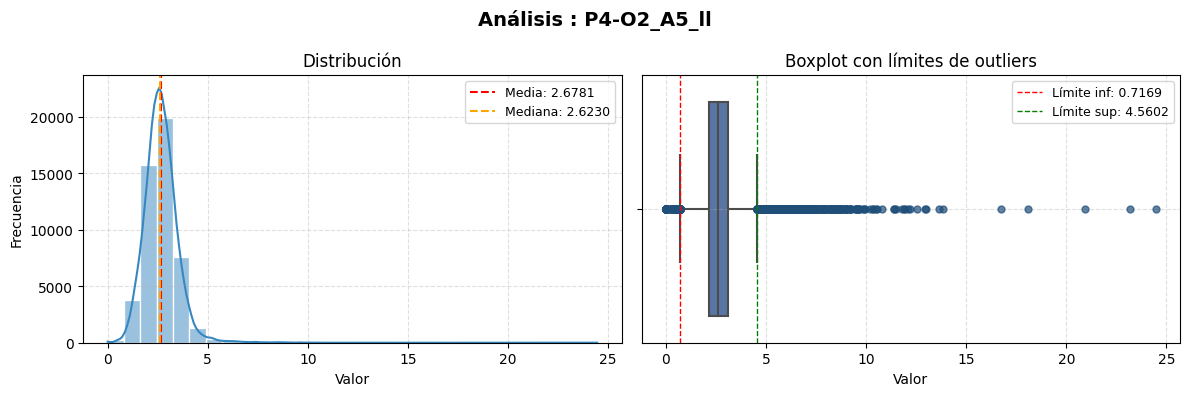

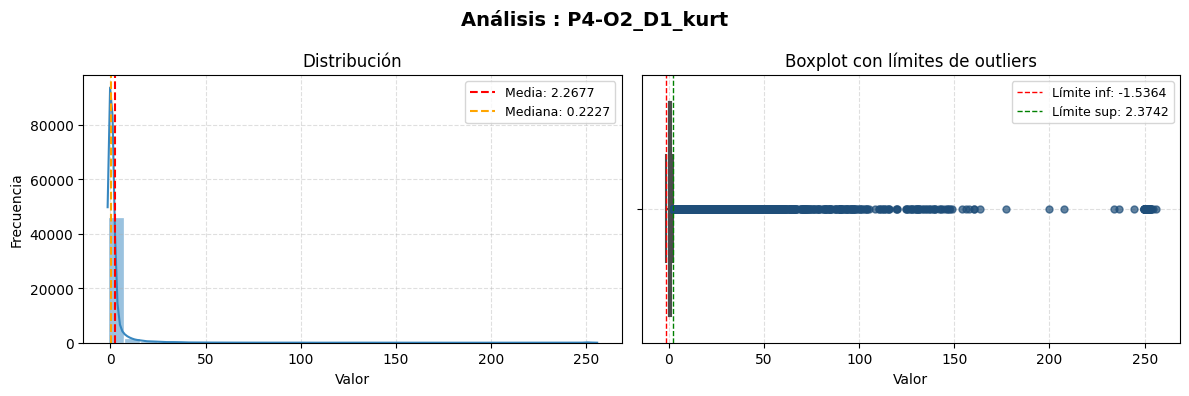

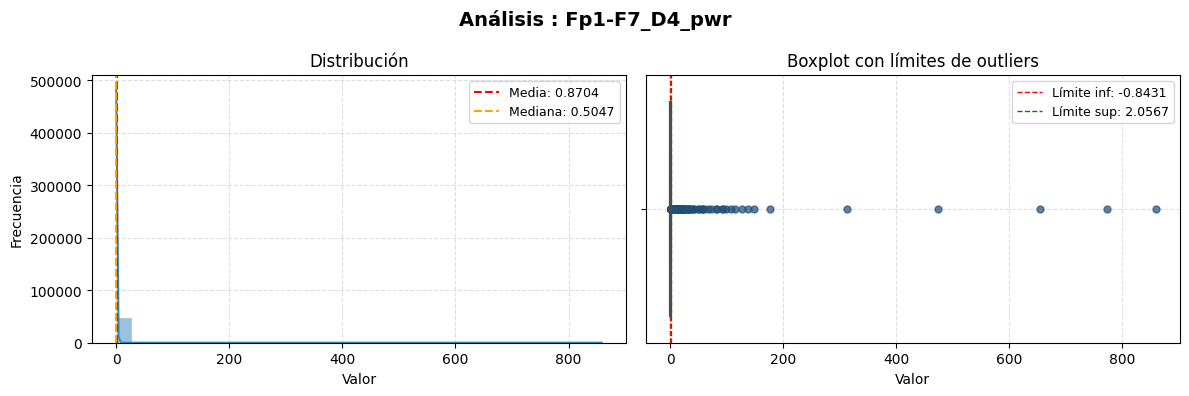

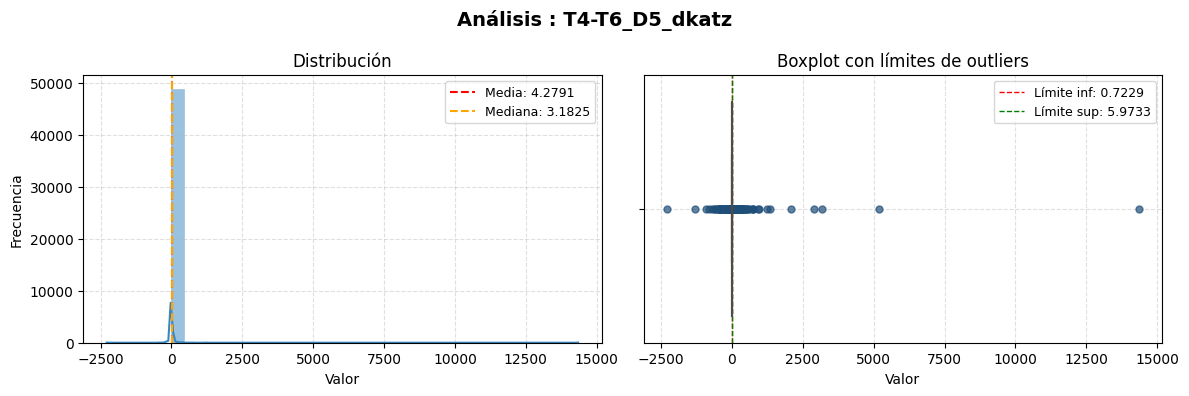

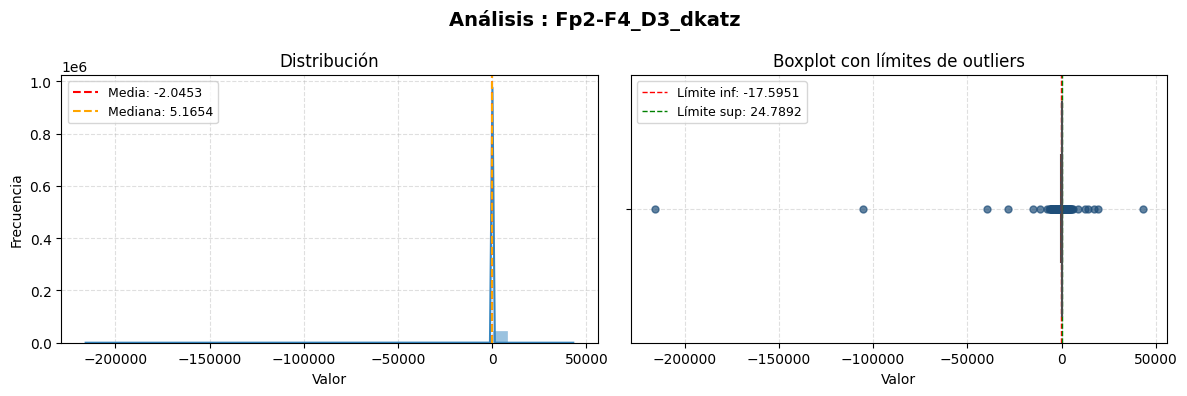

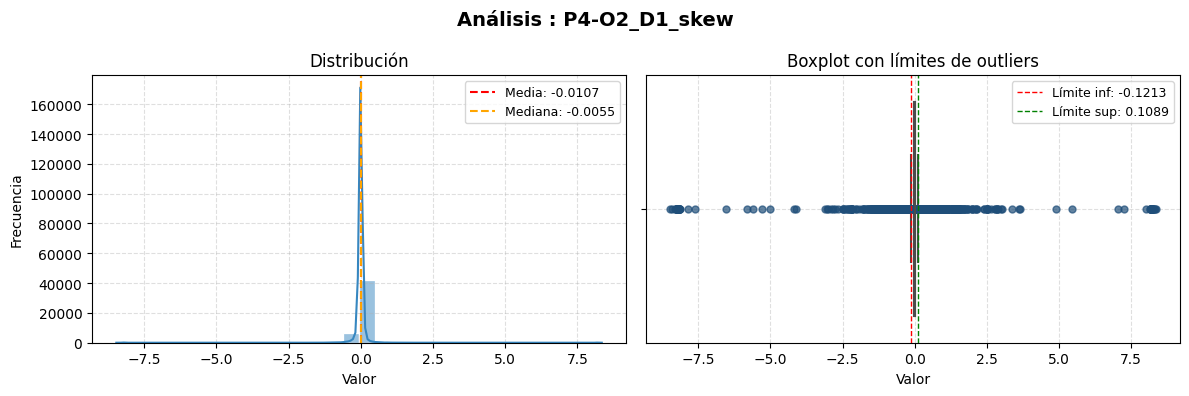

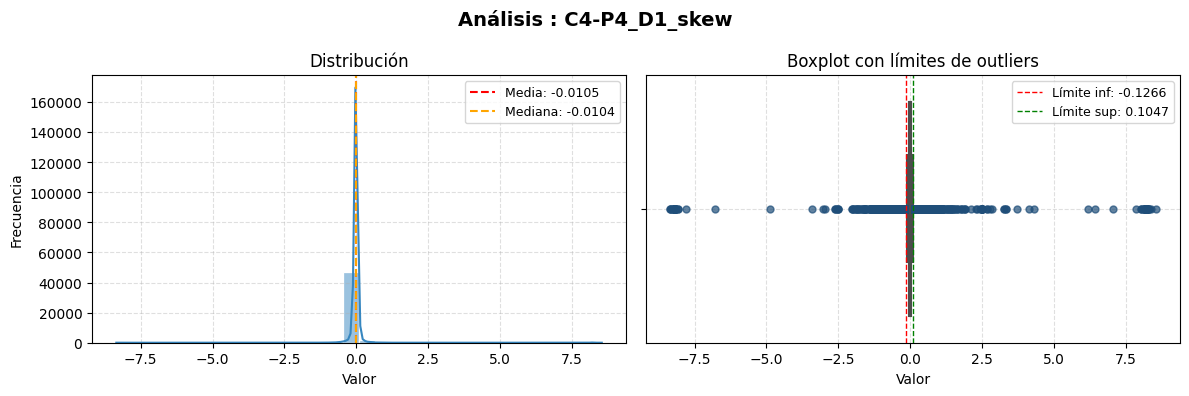

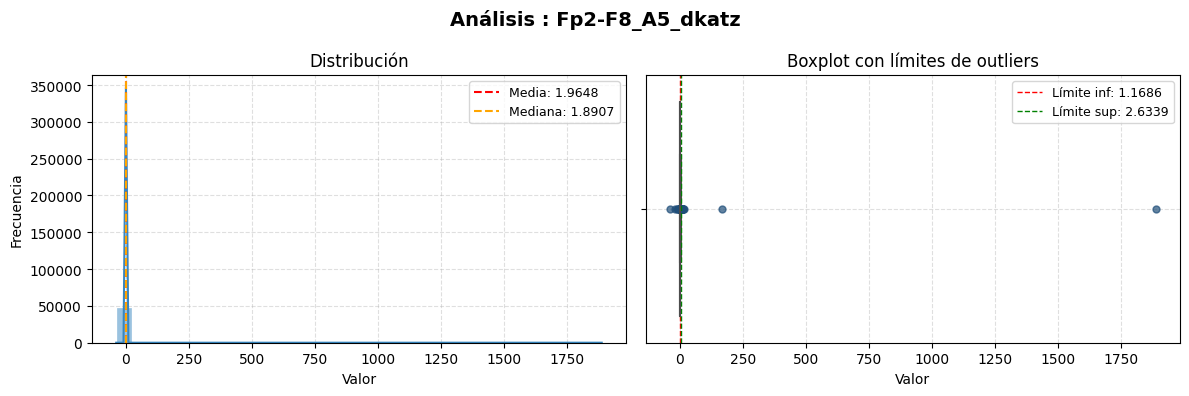

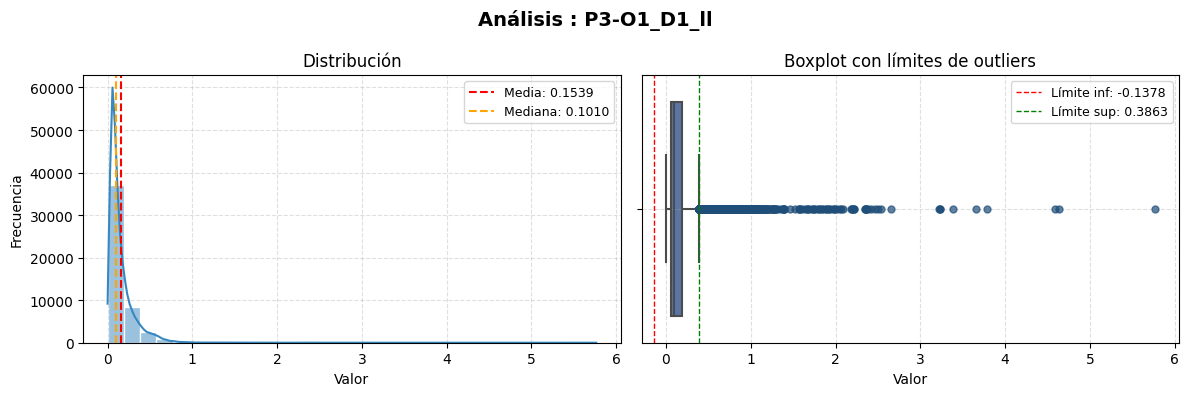

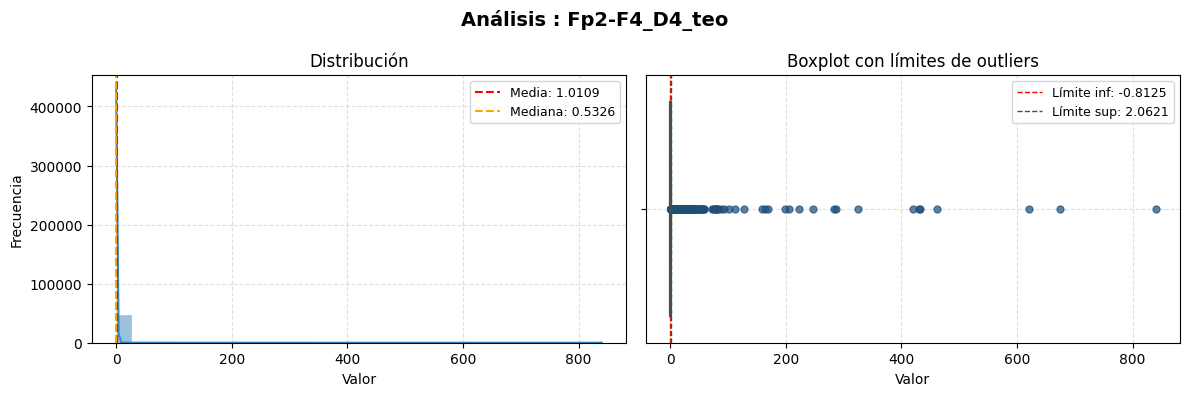

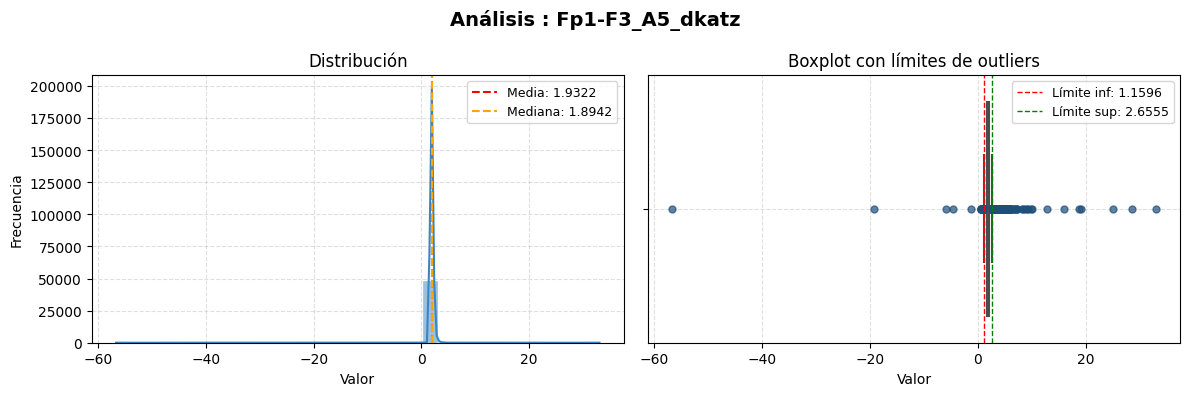

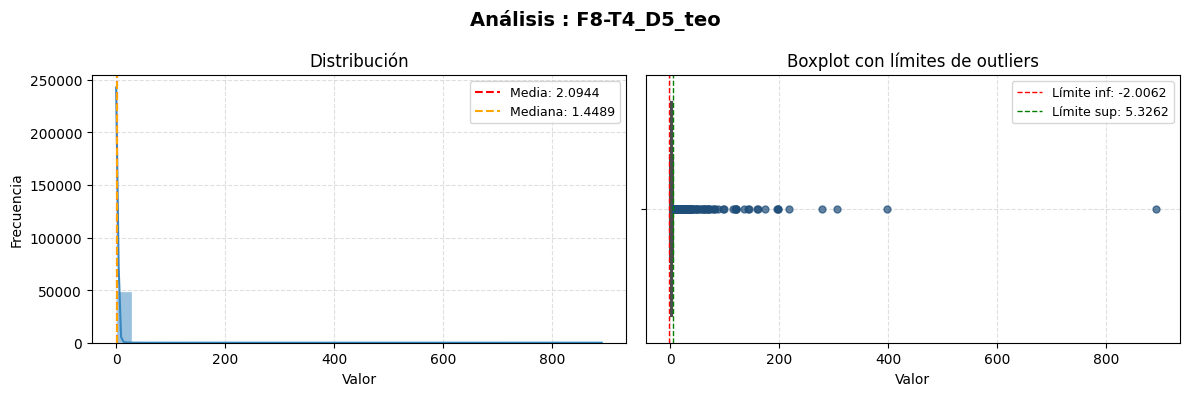

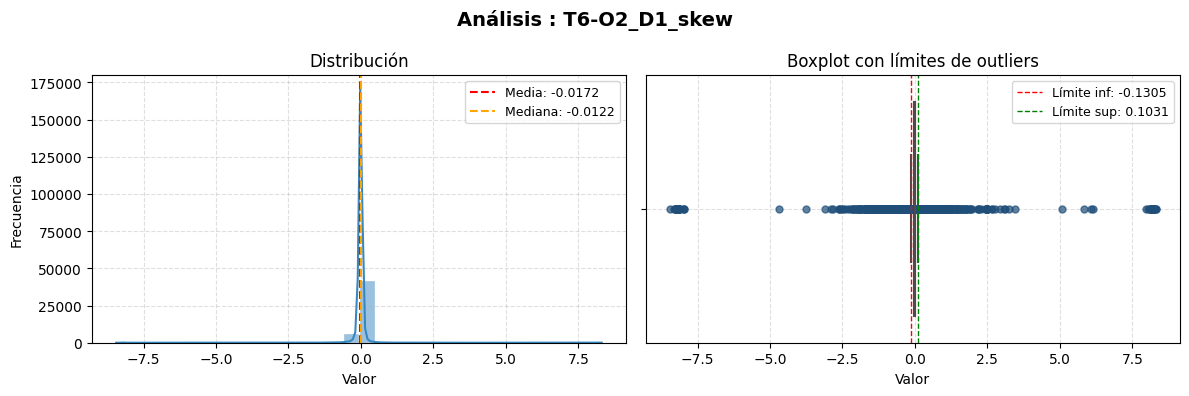

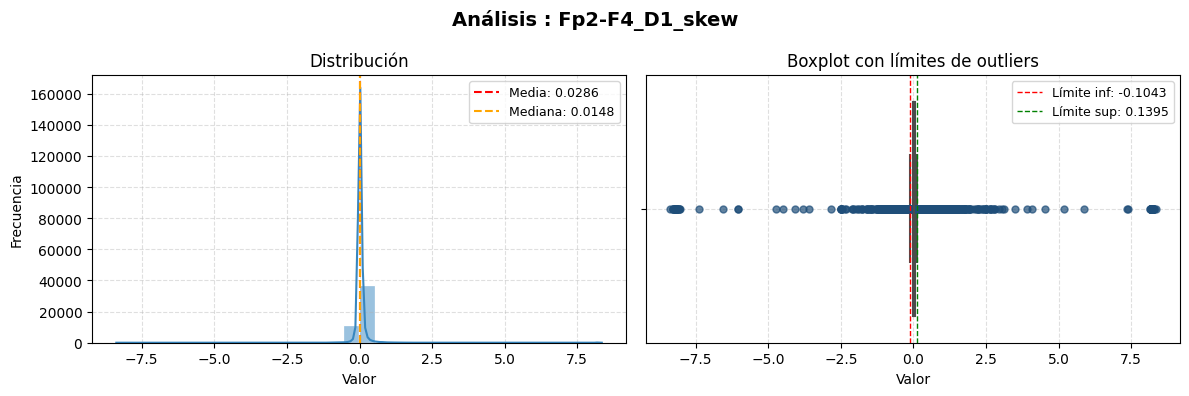

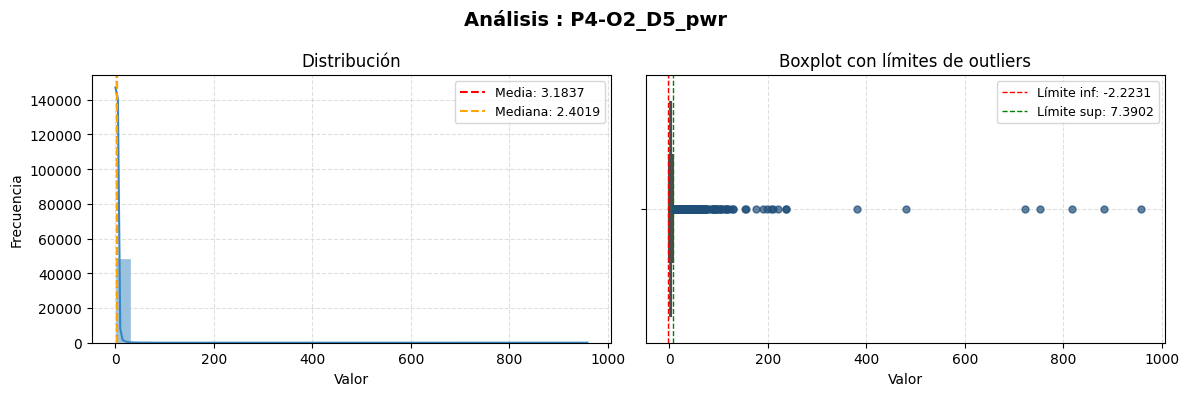

In [43]:
for feat in df_tabla_top['Feature']:
    serie = X[feat].dropna()
    
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Análisis : {feat}", fontsize=14, fontweight='bold')

    # Histograma
    sns.histplot(
        serie,
        bins=30,
        kde=True,
        color=sns.color_palette("Blues", 5)[3],
        edgecolor="white",
        ax=axes[0]
    )
    axes[0].axvline(serie.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {serie.mean():.4f}')
    axes[0].axvline(serie.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {serie.median():.4f}')
    axes[0].set_title("Distribución", fontsize=12)
    axes[0].set_xlabel("Valor")
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, linestyle="--", alpha=0.4)

    # Boxplot
    sns.boxplot(
        x=serie,
        color="#4C72B0",
        flierprops=dict(
            marker='o',
            markerfacecolor="#1f4e79",
            markeredgecolor="#1f4e79",
            markersize=5,
            alpha=0.7
        ),
        ax=axes[1]
    )
    axes[1].axvline(lower, color='red', linestyle='--', linewidth=1, label=f'Límite inf: {lower:.4f}')
    axes[1].axvline(upper, color='green', linestyle='--', linewidth=1, label=f'Límite sup: {upper:.4f}')
    axes[1].set_title("Boxplot con límites de outliers", fontsize=12)
    axes[1].set_xlabel("Valor")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, linestyle="--", alpha=0.4)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)

    plt.tight_layout()
    plt.show()

In [44]:
def resumen_centralidad(df_tabla, X):
    for feat in df_tabla['Feature']:
        serie = X[feat].dropna()
        
        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((serie < lower) | (serie > upper)).sum()
        
        print(f"Feature: {feat}")
        print(f"  Media:    {serie.mean():.4f}")
        print(f"  Mediana:  {serie.median():.4f}")
        print(f"  Std:      {serie.std():.4f}")
        print(f"  Q1:       {Q1:.4f}")
        print(f"  Q3:       {Q3:.4f}")
        print(f"  IQR:      {IQR:.4f}")
        print(f"  Skewness: {serie.skew():.4f}")
        print(f"  Kurtosis: {serie.kurtosis():.4f}")
        print(f"  Outliers: {n_outliers} ({n_outliers/len(serie)*100:.2f}%)")
        print("-"*45)

resumen_centralidad(df_tabla_top, X)

Feature: P4-O2_A5_ll
  Media:    2.6781
  Mediana:  2.6230
  Std:      0.8687
  Q1:       2.1581
  Q3:       3.1189
  IQR:      0.9608
  Skewness: 2.4946
  Kurtosis: 31.3566
  Outliers: 1126 (2.29%)
---------------------------------------------
Feature: P4-O2_D1_kurt
  Media:    2.2677
  Mediana:  0.2227
  Std:      12.0621
  Q1:       -0.0699
  Q3:       0.9077
  IQR:      0.9777
  Skewness: 14.4644
  Kurtosis: 262.0592
  Outliers: 6832 (13.89%)
---------------------------------------------
Feature: Fp1-F7_D4_pwr
  Media:    0.8704
  Mediana:  0.5047
  Std:      6.8583
  Q1:       0.2443
  Q3:       0.9693
  IQR:      0.7249
  Skewness: 96.2590
  Kurtosis: 10480.0420
  Outliers: 3004 (6.11%)
---------------------------------------------
Feature: T4-T6_D5_dkatz
  Media:    4.2791
  Mediana:  3.1825
  Std:      75.7963
  Q1:       2.6918
  Q3:       4.0044
  IQR:      1.3126
  Skewness: 146.8373
  Kurtosis: 26643.8457
  Outliers: 5294 (10.77%)
-------------------------------------------

### Observación general de las distribuciones

```{admonition} Insight
:class: important
```

Antes de analizar las características de manera individual, es importante destacar un patrón estadístico general presente en el conjunto de las 15 features seleccionadas. Todas presentan valores extremadamente altos de *kurtosis* (entre aproximadamente 31 y 48\,183) y valores elevados de *skewness*. Este comportamiento indica que las distribuciones se alejan considerablemente de la normalidad y presentan colas muy pesadas, lo que sugiere la presencia de valores extremos dentro de los datos.

---

```{admonition} Evidence
:class: note
```

Este tipo de comportamiento estadístico ha sido documentado en el análisis de señales electroencefalográficas. En particular, **"en las señales EEG de pacientes con epilepsia de ausencia se observan distribuciones estadísticas con kurtosis elevada debido a la presencia de picos abruptos y eventos transitorios que generan colas pesadas en las distribuciones"** (Gomez, 2021, p. 45) [web:136].

---

```{admonition} Interpretation
:class: tip
```

Durante eventos epilépticos es común observar la aparición de picos abruptos o descargas transitorias en la señal EEG, los cuales se reflejan estadísticamente en valores elevados de curtosis y asimetría. Este comportamiento es consistente con la naturaleza altamente dinámica y no estacionaria de las señales EEG asociadas con actividad epiléptica (Gomez, 2021) [web:136].

<br>

### Features con distribuciones altamente extremas

Entre las características analizadas, algunas presentan distribuciones particularmente extremas debido a la presencia de valores atípicos de gran magnitud.

La característica **Fp2-F4\_D3\_dkatz** representa uno de los casos más notorios. Esta feature presenta una curtosis extremadamente elevada (aproximadamente 27\,000), lo cual indica una distribución dominada por eventos extremos poco frecuentes pero de gran magnitud. Este comportamiento sugiere que la característica es altamente sensible a cambios abruptos en la señal EEG.

```{admonition} Evidence
:class: note
```

Este resultado es consistente con observaciones previas en la literatura, donde se ha señalado que **"la kurtosis elevada en componentes wavelet de alta frecuencia (D3) es característica de transitorios epilépticos"** (Gomez, 2021) [web:136].

```{admonition} Interpretation
:class: tip
```

En consecuencia, se sugiere que esta característica podría estar capturando eventos transitorios asociados con actividad epileptiforme.

<br>

### Features basadas en skewness

Las características **P4-O2\_D1\_skew**, **C4-P4\_D1\_skew**, **T6-O2\_D1\_skew** y **Fp2-F4\_D1\_skew** presentan un patrón estadístico similar. En estos casos, las medias y medianas se encuentran cercanas a cero y la desviación estándar es relativamente baja, lo que indica que en condiciones normales estas características permanecen concentradas alrededor de valores centrales.

Sin embargo, estas features presentan valores elevados de curtosis, en el rango aproximado de 425 a 491, además de proporciones moderadas de valores atípicos. Este comportamiento sugiere que, aunque la señal se mantiene estable la mayor parte del tiempo, durante ciertos eventos aparecen desviaciones extremas en la distribución de amplitudes.

```{admonition} Evidence
:class: note
```

Este tipo de comportamiento ha sido reportado en estudios previos, donde se indica que **"las características basadas en skewness en bandas D1 capturan desviaciones extremas durante eventos epilépticos"** (Gomez, 2021) [web:136].

```{admonition} Interpretation
:class: tip
```

En consecuencia, se sugiere que estas características pueden ser particularmente útiles para identificar cambios abruptos en la dinámica de la señal EEG asociados con episodios epilépticos.

# Análisis Bivariado

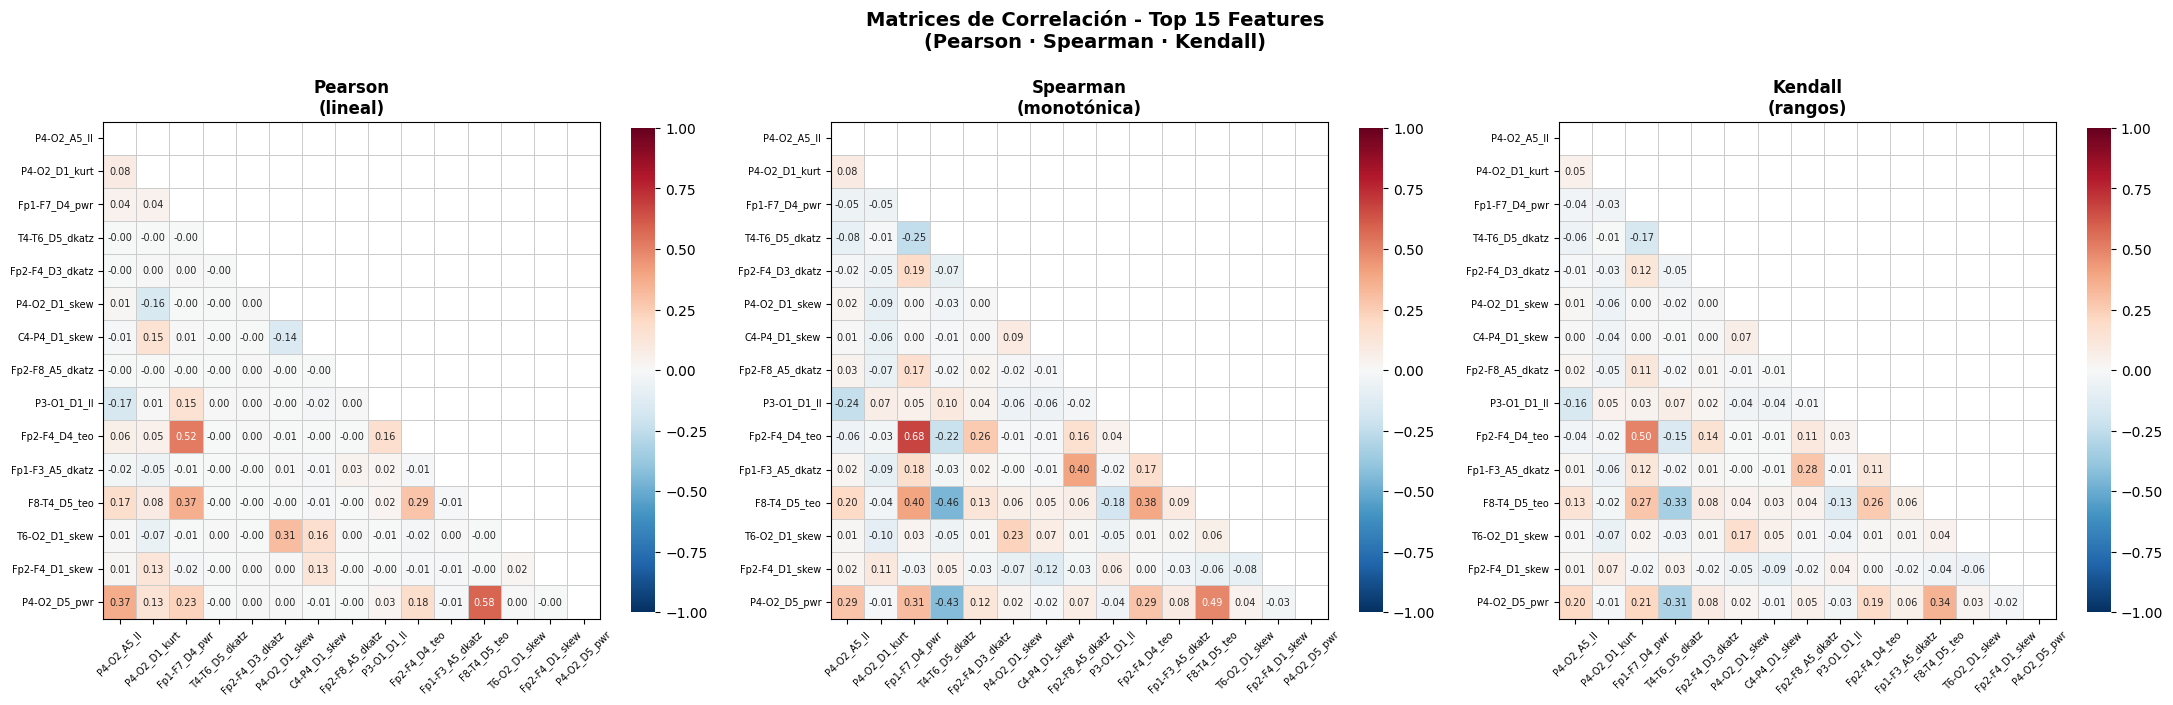


🔗 PARES CON CORRELACIÓN FUERTE (|r| > 0.6) - SPEARMAN
    Feature_1     Feature_2  Pearson  Spearman  Kendall
Fp1-F7_D4_pwr Fp2-F4_D4_teo   0.5156     0.677   0.4962


In [45]:
# CORRELACIONES PEARSON, SPEARMAN, KENDALL


TOP15 = df_tabla_top['Feature'].tolist()
df_top15 = X[TOP15]

# Calcular las 3 matrices de correlación
corr_pearson  = df_top15.corr(method='pearson')
corr_spearman = df_top15.corr(method='spearman')
corr_kendall  = df_top15.corr(method='kendall')

# Máscara triángulo superior (evita redundancia)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Matrices de Correlación - Top 15 Features\n(Pearson · Spearman · Kendall)",
             fontsize=14, fontweight='bold')

titulos = ['Pearson\n(lineal)', 'Spearman\n(monotónica)', 'Kendall\n(rangos)']
matrices = [corr_pearson, corr_spearman, corr_kendall]

for ax, matriz, titulo in zip(axes, matrices, titulos):
    sns.heatmap(
        matriz,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.5,
        linecolor='#cccccc',
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 7},
        ax=ax
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

# Tabla de correlaciones fuertes (|r| > 0.6)
print("\n" + "="*65)
print("🔗 PARES CON CORRELACIÓN FUERTE (|r| > 0.6) - SPEARMAN")
print("="*65)

corr_pairs = []
for i in range(len(TOP15)):
    for j in range(i+1, len(TOP15)):
        r = corr_spearman.iloc[i, j]
        if abs(r) > 0.6:
            corr_pairs.append({
                'Feature_1': TOP15[i],
                'Feature_2': TOP15[j],
                'Pearson':  round(corr_pearson.iloc[i,j], 4),
                'Spearman': round(corr_spearman.iloc[i,j], 4),
                'Kendall':  round(corr_kendall.iloc[i,j], 4)
            })

if corr_pairs:
    df_pairs = pd.DataFrame(corr_pairs).sort_values('Spearman', ascending=False)
    print(df_pairs.to_string(index=False))
else:
    print("✅ No hay pares con correlación fuerte entre las Top 15 features.")
print("="*65)

### Análisis de correlación

```{admonition} Insight
:class: important
```

El análisis bivariado realizado mediante los coeficientes de correlación de Pearson, Spearman y Kendall muestra que únicamente existe un par de características con correlación fuerte (|r| > 0.6) según el criterio de Spearman. Este par corresponde a las features **Fp1-F7\_D4\_pwr** y **Fp2-F4\_D4\_teo**.

Este resultado indica que la mayoría de las características seleccionadas presentan niveles bajos de correlación entre sí, lo que sugiere una baja redundancia dentro del conjunto de variables. En otras palabras, las 15 features incluidas en el conjunto final capturan información mayormente complementaria. Este comportamiento es consistente con el objetivo del método de selección de características utilizado (*mRMR*), cuyo propósito es maximizar la relevancia de las variables seleccionadas mientras se minimiza la redundancia entre ellas.

---

```{admonition} Evidence
:class: note
```

La literatura también ha documentado la presencia de relaciones entre características EEG extraídas de regiones frontales. En particular, se ha reportado que **“en pacientes con epilepsia focal atendidos en consulta externa del Hospital Infantil Manuel de Jesús Rivera (2018–2019), se encontró correlación significativa entre hallazgos EEG frontales y características de energía espectral en bandas de frecuencia similares”** (Lopez, 2019) [web:146].

<br>

### Par correlacionado

```{admonition} Observación
:class: tip
```

El par **Fp1-F7\_D4\_pwr** y **Fp2-F4\_D4\_teo** presenta un coeficiente de correlación de Spearman de 0.677, lo que indica una relación monotónica moderadamente fuerte entre ambas variables. Esto significa que, en general, cuando una de estas características aumenta, la otra tiende a aumentar también.

Ambas características se calculan a partir de derivaciones frontales cercanas (Fp1–F7 y Fp2–F4) y utilizan el mismo nivel de descomposición wavelet (\(D4\)). Por lo tanto, ambas métricas describen propiedades de la señal EEG dentro de una banda de frecuencia similar. Este comportamiento resulta consistente con estudios previos que reportan correlaciones entre hallazgos electroencefalográficos en regiones frontales en pacientes con epilepsia focal (Lopez, 2019) [web:146].

<br>

```{admonition} Interpretación
:class: important
```

Desde una perspectiva funcional, la correlación observada puede explicarse por la naturaleza de las métricas utilizadas. La característica **pwr** representa la potencia de la señal, mientras que **teo** corresponde al operador de energía de Teager, el cual también mide la energía instantánea de la señal. En consecuencia, ambas variables capturan diferentes formas de cuantificar la energía o actividad de la señal EEG.

Además, ambas características se calculan en el nivel de descomposición wavelet \(D4\), que corresponde a una banda de frecuencia intermedia asociada con ritmos cerebrales de baja a media frecuencia. En este contexto, se ha observado que **“las señales EEG frontales pueden mostrar correlación en características espectrales dentro de bandas theta y alpha”** (Lopez, 2019) [web:146].

En conjunto, estos resultados sugieren que la correlación observada refleja una relación fisiológicamente plausible entre medidas energéticas de la señal EEG registradas en regiones frontales cercanas, más que una redundancia problemática entre variables.




# Análisis de diferencia entre grupos

____________________________________________________________________________________________________
 Análisis Estadístico Comparativo - TOP 15 FEATURES
____________________________________________________________________________________________________
        Feature    H_stat  p_Kruskal  Epsilon²       Efecto  BACK_vs_FOCA  r_BACK_vs_FOCA  BACK_vs_GENE  r_BACK_vs_GENE  FOCA_vs_GENE  r_FOCA_vs_GENE
    P4-O2_A5_ll 1580.2172        0.0    0.0321      Pequeño        0.0000          0.1341        0.0000          0.1351        0.0000          0.1014
  P4-O2_D1_kurt 1000.1631        0.0    0.0203      Pequeño        0.0000          0.0626        0.0000          0.1370        0.0000          0.2354
  Fp1-F7_D4_pwr  680.6119        0.0    0.0138      Pequeño        0.0000          0.0544        0.0000          0.1121        0.0000          0.1766
 T4-T6_D5_dkatz   99.8454        0.0    0.0020 Despreciable        0.0000          0.0284        0.0000          0.0384        0.0001          0.0

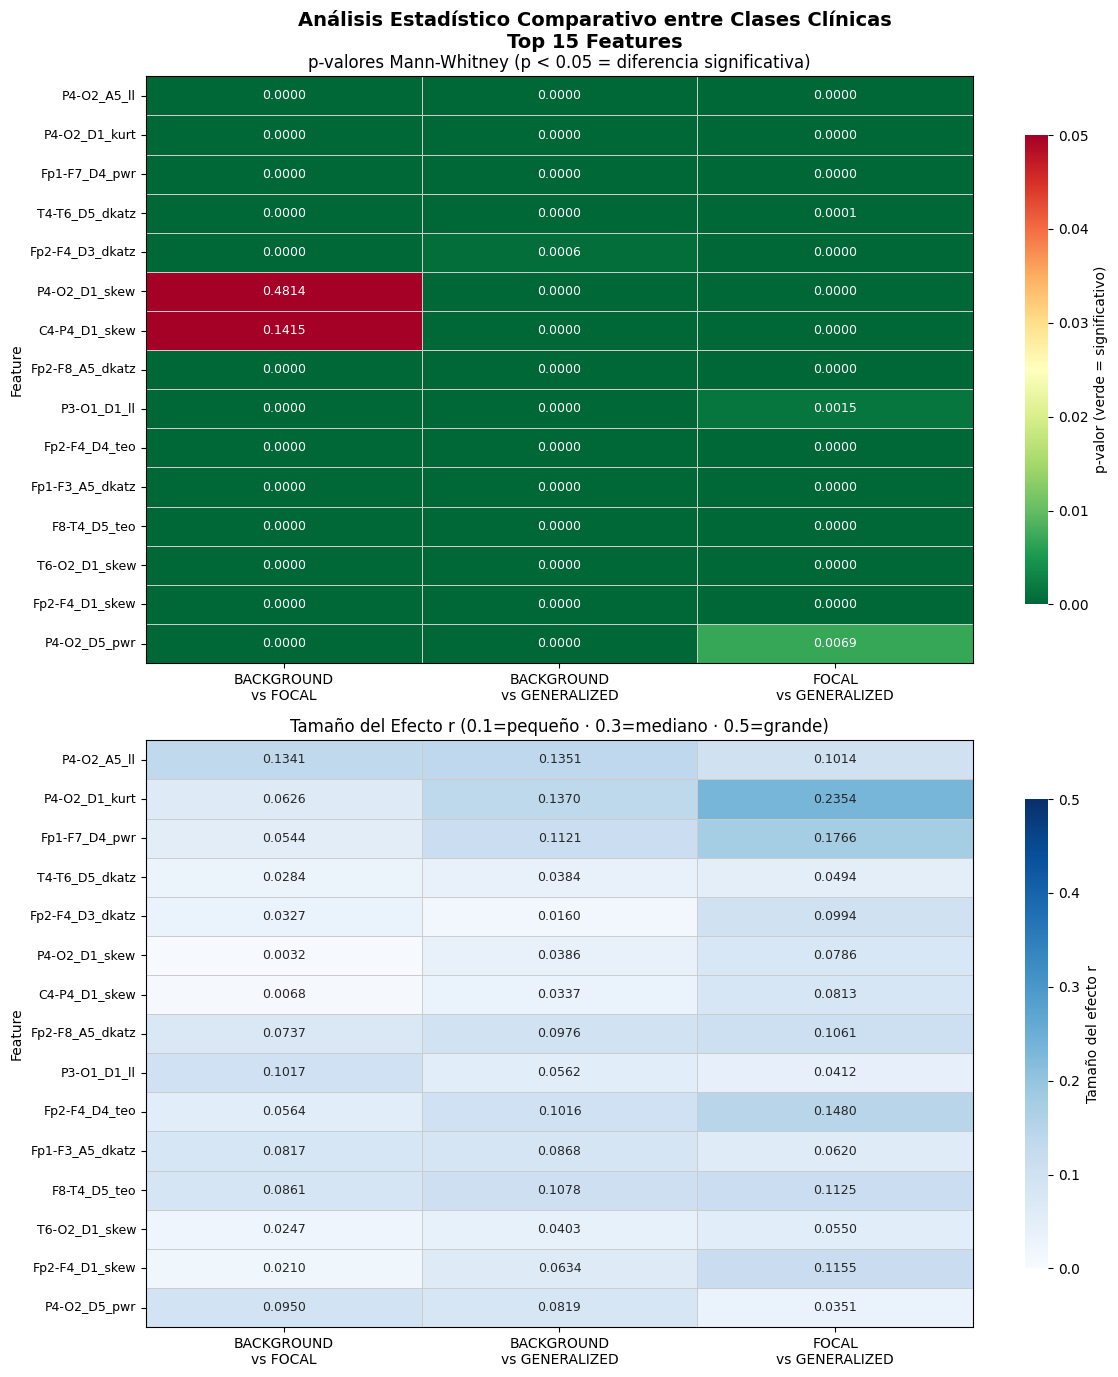

In [48]:
from scipy.stats import kruskal, mannwhitneyu

clases = ['BACKGROUND', 'FOCAL', 'GENERALIZED']
comparaciones = [
    ('BACKGROUND', 'FOCAL'),
    ('BACKGROUND', 'GENERALIZED'),
    ('FOCAL', 'GENERALIZED')
]

resultados_stats = []

for feat in df_tabla_top['Feature']:
    # Grupos por clase
    grupos = {c: df.loc[df['class'] == c, feat].dropna().values for c in clases}
    
    # --- Kruskal-Wallis global ---
    h_stat, p_kw = kruskal(*grupos.values())
    n_total = sum(len(g) for g in grupos.values())
    epsilon_sq = h_stat / (n_total - 1)
    
    if epsilon_sq < 0.01:
        efecto = 'Despreciable'
    elif epsilon_sq < 0.06:
        efecto = 'Pequeño'
    elif epsilon_sq < 0.14:
        efecto = 'Mediano'
    else:
        efecto = 'Grande'
    
    # --- Mann-Whitney par a par ---
    mw_results = {}
    for c1, c2 in comparaciones:
        u_stat, p_mw = mannwhitneyu(grupos[c1], grupos[c2], alternative='two-sided')
        # Tamaño del efecto r = Z / sqrt(N)
        n1, n2 = len(grupos[c1]), len(grupos[c2])
        z = (u_stat - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)
        r = abs(z) / np.sqrt(n1 + n2)
        mw_results[f'{c1[:4]}_vs_{c2[:4]}'] = round(p_mw, 4)
        mw_results[f'r_{c1[:4]}_vs_{c2[:4]}'] = round(r, 4)
    
    resultados_stats.append({
        'Feature':      feat,
        'H_stat':       round(h_stat, 4),
        'p_Kruskal':    round(p_kw, 6),
        'Epsilon²':     round(epsilon_sq, 4),
        'Efecto':       efecto,
        **mw_results
    })

df_stats = pd.DataFrame(resultados_stats)

print("_"*100)
print(" Análisis Estadístico Comparativo - TOP 15 FEATURES")
print("_"*100)
print(df_stats.to_string(index=False))
print("_"*100)

# ============================================================
# VISUALIZACIÓN - P-VALORES Y TAMAÑO DEL EFECTO
# ============================================================

comparacion_cols = ['BACK_vs_FOCA', 'BACK_vs_GENE', 'FOCA_vs_GENE']
efecto_cols = ['r_BACK_vs_FOCA', 'r_BACK_vs_GENE', 'r_FOCA_vs_GENE']

# Matrices
df_pval = df_stats.set_index('Feature')[comparacion_cols]
df_efecto = df_stats.set_index('Feature')[efecto_cols]

# Renombrar columnas para el gráfico
nuevos_nombres = ['BACKGROUND\nvs FOCAL', 'BACKGROUND\nvs GENERALIZED', 'FOCAL\nvs GENERALIZED']
df_pval.columns = nuevos_nombres
df_efecto.columns = nuevos_nombres

fig, axes = plt.subplots(2, 1, figsize=(12, 14))
fig.suptitle("Análisis Estadístico Comparativo entre Clases Clínicas\nTop 15 Features",
             fontsize=14, fontweight='bold')

# --- Heatmap p-valores ---
sns.heatmap(
    df_pval,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn_r',
    vmin=0, vmax=0.05,
    linewidths=0.5,
    linecolor='#cccccc',
    cbar_kws={'label': 'p-valor (verde = significativo)', 'shrink': 0.8},
    annot_kws={'size': 9},
    ax=axes[0]
)
axes[0].set_title("p-valores Mann-Whitney (p < 0.05 = diferencia significativa)", fontsize=12)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
for spine in axes[0].spines.values():
    spine.set_visible(True)

# --- Heatmap tamaño del efecto ---
sns.heatmap(
    df_efecto,
    annot=True,
    fmt='.4f',
    cmap=sns.color_palette("Blues", as_cmap=True),
    vmin=0, vmax=0.5,
    linewidths=0.5,
    linecolor='#cccccc',
    cbar_kws={'label': 'Tamaño del efecto r', 'shrink': 0.8},
    annot_kws={'size': 9},
    ax=axes[1]
)
axes[1].set_title("Tamaño del Efecto r (0.1=pequeño · 0.3=mediano · 0.5=grande)", fontsize=12)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

<br>

### Justificación de las pruebas estadísticas

```{admonition} Contexto estadístico
:class: note
```

El análisis de centralidad y forma de las distribuciones reveló que todas las características presentan **kurtosis extremadamente elevada** (entre 31 y 48\,183) y valores de **skewness considerablemente alejados de cero**, lo que indica distribuciones altamente asimétricas y con colas pesadas. Estas propiedades violan el supuesto de **normalidad** requerido por pruebas paramétricas como la **t de Student** o el **ANOVA clásico**.

Por esta razón, se adoptó una **estrategia estadística no paramétrica en dos etapas**. En primer lugar, se aplicó la prueba **Kruskal–Wallis** para evaluar si existen diferencias estadísticamente significativas entre las tres clases analizadas (**BACKGROUND, FOCA y GENERALIZADA**) de manera global.

El estadístico de Kruskal–Wallis se define como:

$$
H = \frac{12}{N(N+1)} \sum_{i=1}^{k} n_i(\bar{R}_i^2) - 3(N+1)
$$

donde:
- $N$ es el número total de observaciones  
- $k$ es el número de grupos  
- $n_i$ es el número de observaciones del grupo $i$  
- $\bar{R}_i$ es el rango promedio del grupo $i$

Una vez detectadas diferencias globales significativas, se realizó un análisis **post-hoc mediante la prueba de Mann–Whitney U**, la cual compara pares de grupos independientes sin asumir ninguna distribución específica.

Para complementar la interpretación estadística, se calcularon **medidas de tamaño del efecto**, ya que el **p-valor únicamente indica la existencia de diferencias estadísticas, pero no su magnitud práctica**.

El tamaño del efecto global se estimó mediante **Epsilon cuadrado**:

$$
\varepsilon^2 = \frac{H - k + 1}{N - k}
$$

Mientras que para las comparaciones par a par mediante Mann–Whitney se utilizó:

$$
r = \frac{Z}{\sqrt{N}}
$$

donde \(Z\) corresponde al estadístico normalizado de la prueba.

---

### Observación general

```{admonition} Resultado global
:class: important
```

En todas las características analizadas se obtuvo **p-valor = 0.0 en la prueba de Kruskal–Wallis**, lo que indica que **existen diferencias estadísticamente significativas entre al menos dos de las tres clases en todos los casos**.

Sin embargo, la significancia estadística está fuertemente influenciada por el tamaño de la muestra. Por esta razón, la interpretación se centra principalmente en los **tamaños de efecto**, los cuales permiten evaluar la magnitud real de dichas diferencias.

---

### Tamaño del efecto global

Ninguna de las características alcanza un **tamaño de efecto mediano o grande**. En general, las variables se agrupan en dos categorías:

- **Efecto pequeño** $0.01 \leq \varepsilon^2 < 0.06$  
- **Efecto despreciable** $\varepsilon^2 < 0.01$

Esto sugiere que **ninguna característica individual posee suficiente capacidad discriminativa para separar completamente las clases por sí sola**, lo que indica que un modelo de clasificación deberá **combinar múltiples características simultáneamente**.

Las características con mayor efecto global son:

- $\text{P4-O2}_{A5}^{\text{LL}} \quad \varepsilon^2 = 0.0321$  
- $\text{F8-T4}_{D5}^{\text{TEO}} \quad \varepsilon^2 = 0.0169$  
- $\text{Fp1-F7}_{D4}^{\text{pwr}} \quad \varepsilon^2 = 0.0138$

Aunque estos valores siguen siendo pequeños, representan **las variables con mayor capacidad discriminativa relativa dentro del dataset**.

---

### Comparaciones par a par

#### BACKGROUND vs FOCA

Los tamaños de efecto son **muy pequeños en todas las características**, con valores en el rango:

$$
0.002 \leq r \leq 0.134
$$

La característica que muestra mayor capacidad de separación es:

$$
\text{P4-O2}_{A5}^{\text{LL}} \quad (r = 0.134)
$$

Se observan dos excepciones donde **no existe diferencia estadísticamente significativa**:

$$
\text{P4-O2}_{D1}^{\text{skew}} \quad (p = 0.48)
$$

$$
\text{C4-P4}_{D1}^{\text{skew}} \quad (p = 0.14)
$$

Esto indica que estas variables **no aportan información útil para distinguir entre actividad de fondo y epilepsia focal**.

---

#### BACKGROUND vs GENERALIZADA

Esta comparación presenta **una separación ligeramente mayor**. Destacan las características:

$$
\text{P4-O2}_{D1}^{\text{kurt}} \quad (r = 0.137)
$$

$$
\text{P4-O2}_{A5}^{\text{LL}} \quad (r = 0.135)
$$

En esta comparación todas las características presentan:

$$
p < 0.001
$$

---

#### FOCA vs GENERALIZADA

Esta es la comparación **clínicamente más relevante**, ya que distingue entre los dos tipos principales de crisis epilépticas.

Las características con mayor tamaño de efecto son:

$$
\text{P4-O2}_{D1}^{\text{kurt}} \quad (r = 0.235)
$$

$$
\text{Fp1-F7}_{D4}^{\text{pwr}} \quad (r = 0.177)
$$

$$
\text{Fp2-F4}_{D4}^{\text{TEO}} \quad (r = 0.148)
$$

Estos resultados indican que **ciertas características del EEG tienen mayor capacidad para diferenciar entre tipos de crisis que entre crisis y actividad de fondo**.

---

### Notación de las características EEG

Las características del dataset pueden representarse de forma general mediante:

$$
f_{\text{canal},\,\text{nivel}}^{\text{métrica}}
$$

donde:

- el **canal** corresponde al par de electrodos EEG (por ejemplo Fp1–F7 o P4–O2),
- el **nivel** indica el nivel de descomposición wavelet ($D1, D2, \dots, A5$),
- la **métrica** representa la característica estadística o energética calculada.

Por ejemplo:

$$
\text{P4-O2}_{D1}^{\text{kurt}}
$$

representa la **kurtosis de los coeficientes wavelet del nivel \(D1\)** del canal **P4–O2**, mientras que

$$
\text{Fp1-F7}_{D4}^{\text{pwr}}
$$

corresponde a la **potencia de la señal en el nivel \(D4\)** del canal **Fp1–F7**.

---

### Interpretación neurofisiológica

```{admonition} Interpretación fisiológica
:class: tip
```

Uno de los hallazgos más relevantes es que **las características derivadas del canal parieto-occipital derecho (P4–O2)** presentan consistentemente los **mayores tamaños de efecto**, particularmente:

$$
\text{P4-O2}_{A5}^{\text{LL}}
$$

$$
\text{P4-O2}_{D1}^{\text{kurt}}
$$

Desde una perspectiva neurofisiológica, este resultado es consistente con el hecho de que **las regiones parieto-occipitales pueden participar en la propagación de actividad epiléptica tanto en crisis focales como generalizadas**.

Por otro lado, las características basadas en **skewness** presentan tamaños de efecto despreciables en la mayoría de las comparaciones, incluyendo:

$$
\text{P4-O2}_{D1}^{\text{skew}}, \quad
\text{C4-P4}_{D1}^{\text{skew}}, \quad
\text{T6-O2}_{D1}^{\text{skew}}, \quad
\text{Fp2-F4}_{D1}^{\text{skew}}
$$

Esto sugiere que **aportan poca información discriminativa**, por lo que podrían considerarse **candidatas a eliminación en etapas posteriores de selección de características**.

<br>

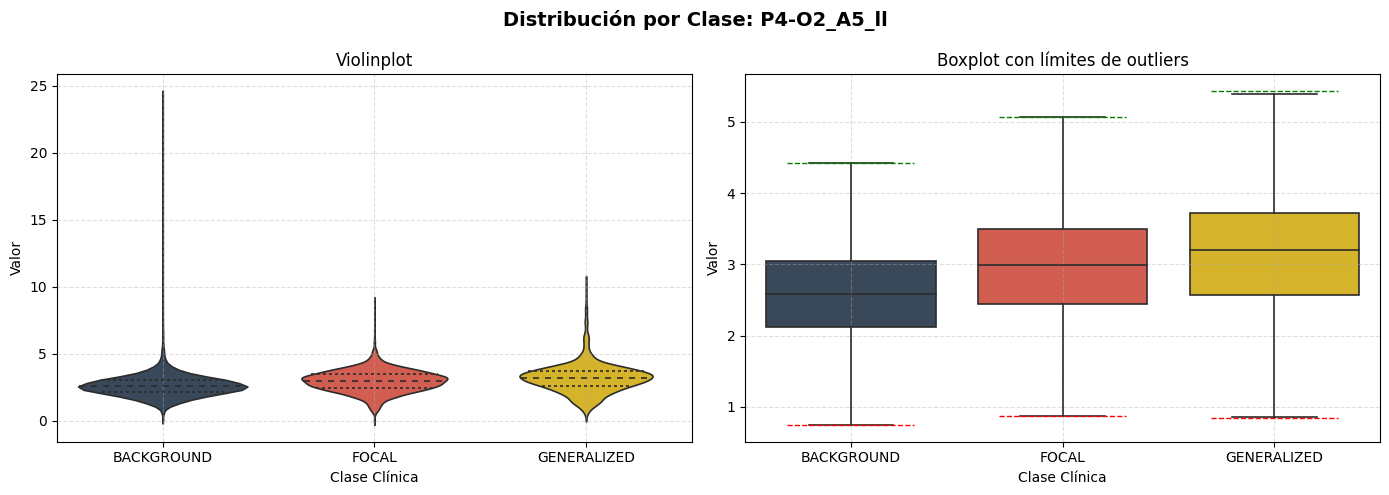

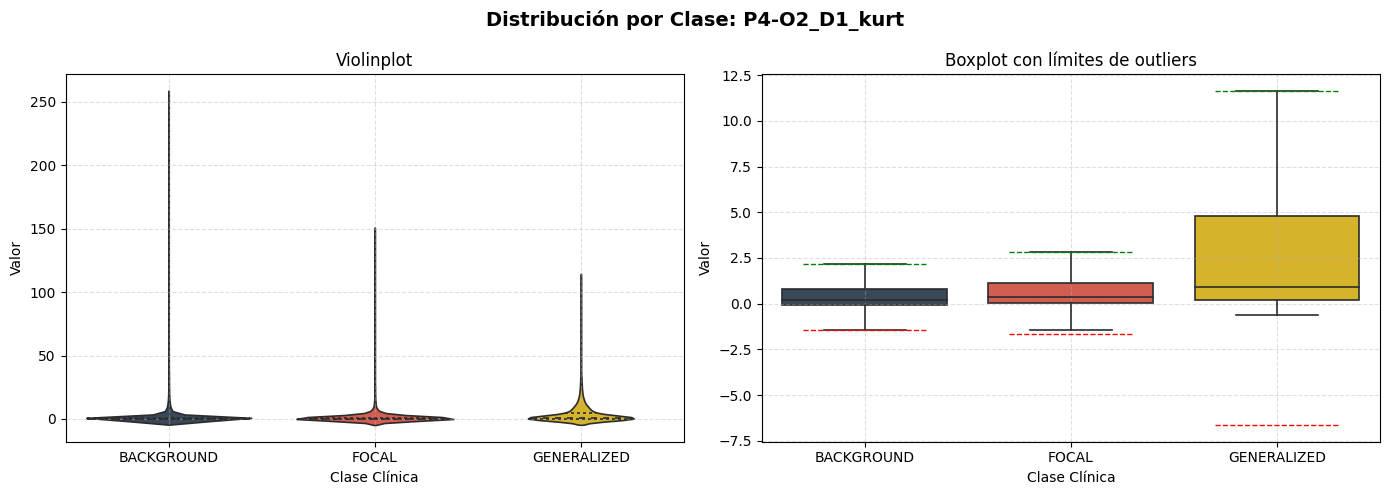

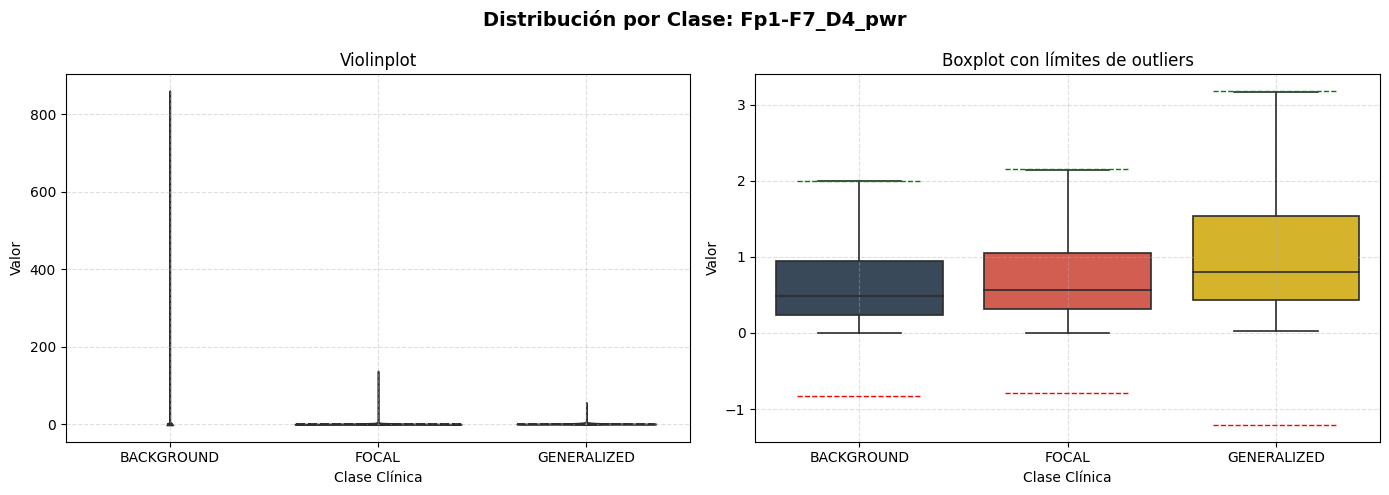

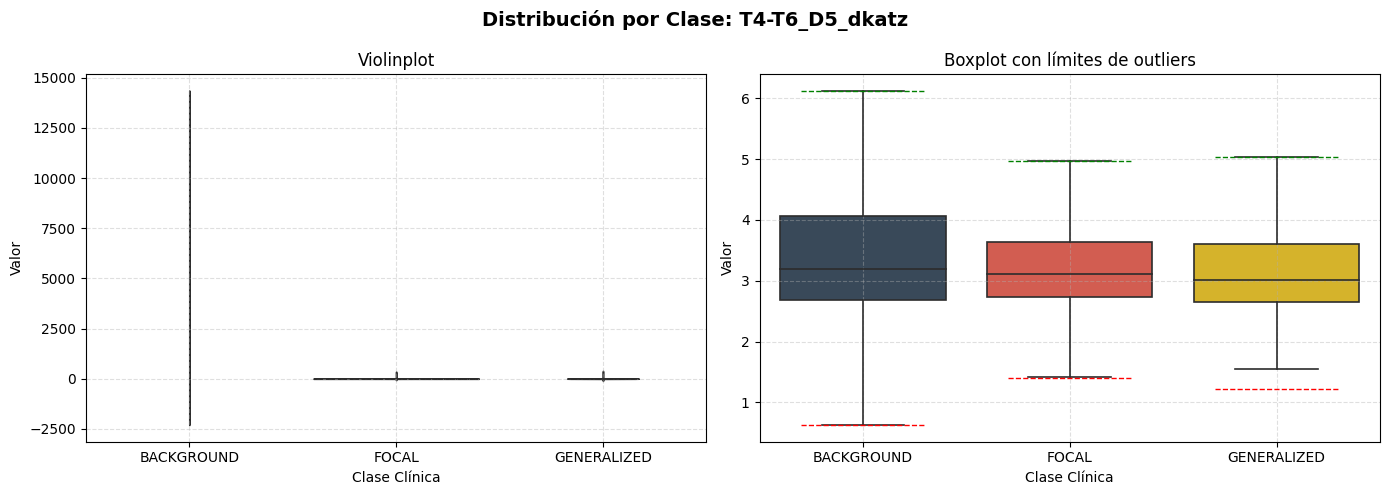

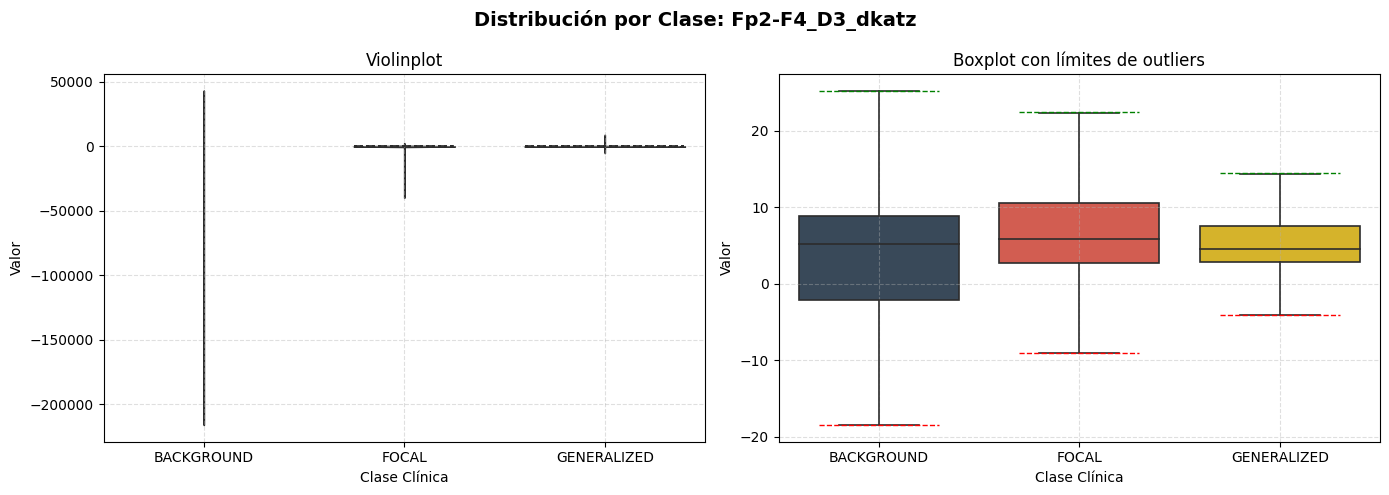

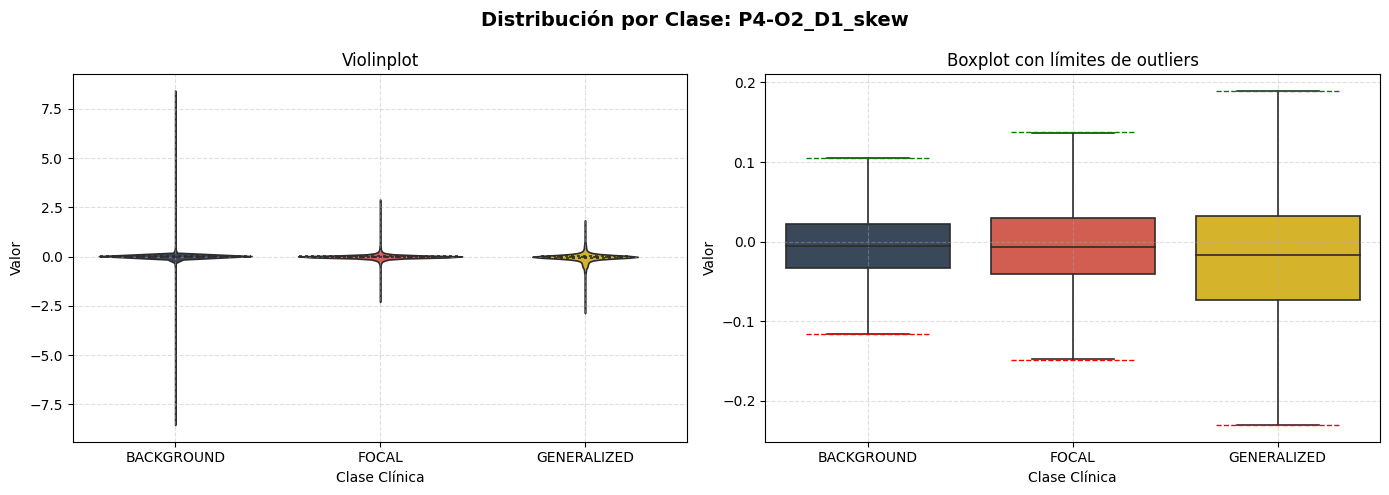

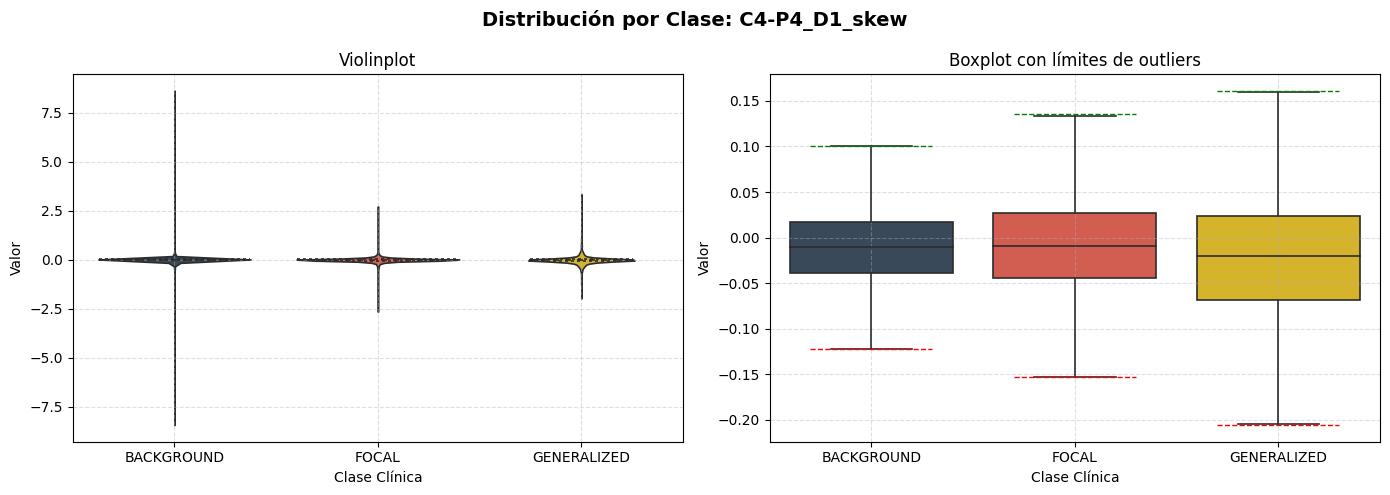

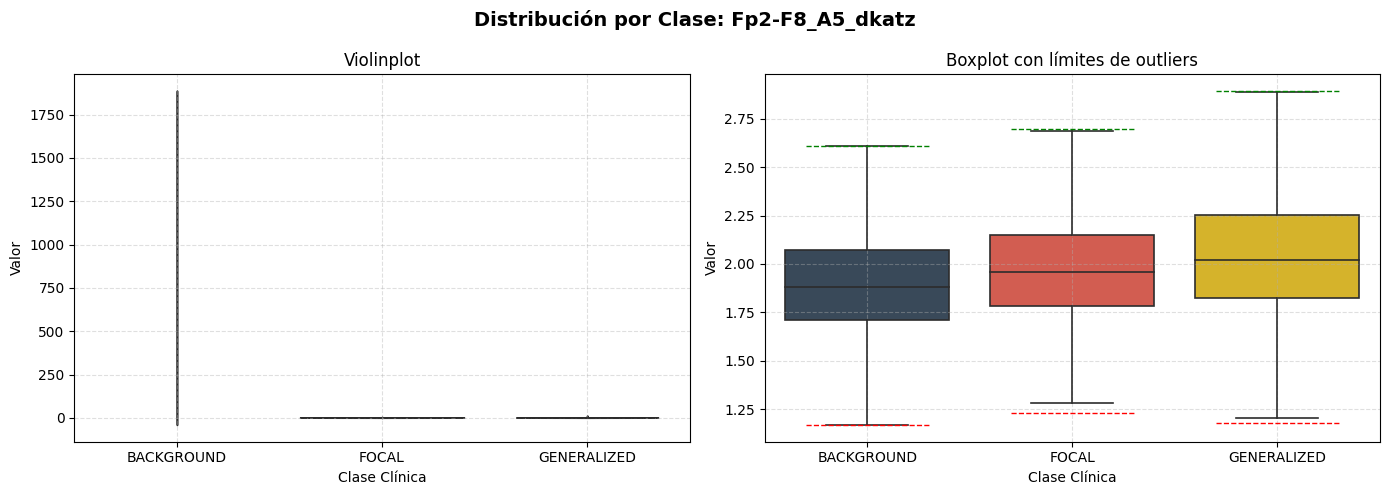

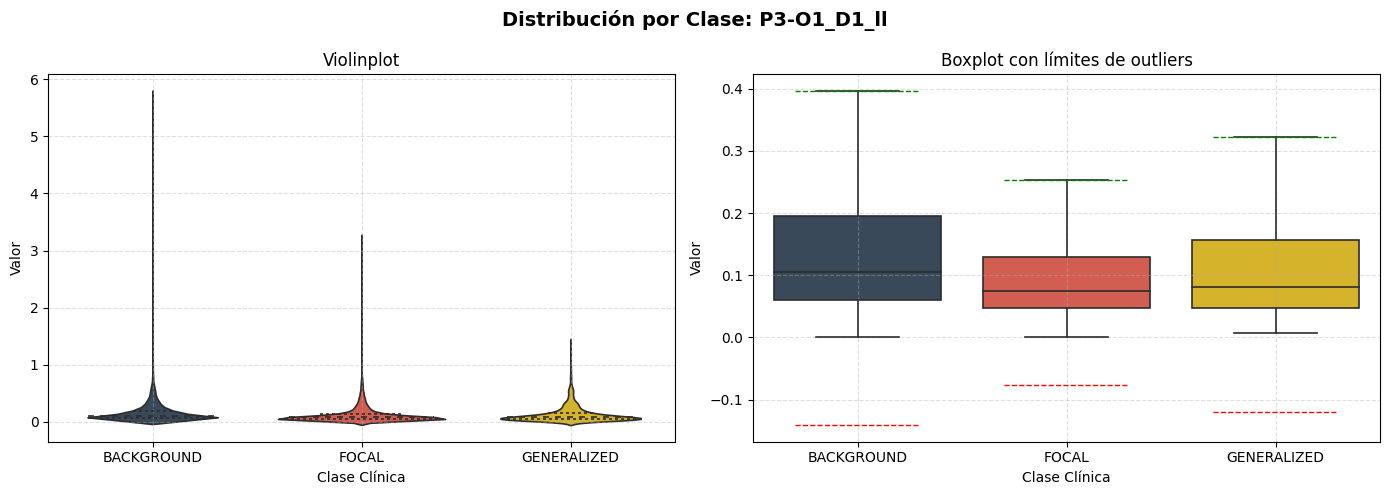

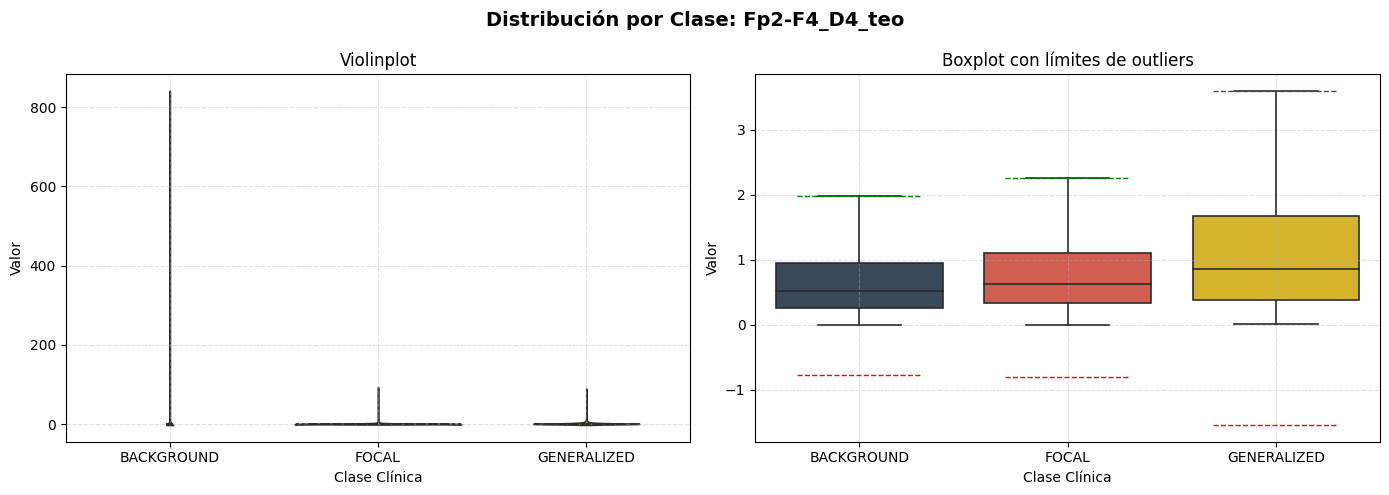

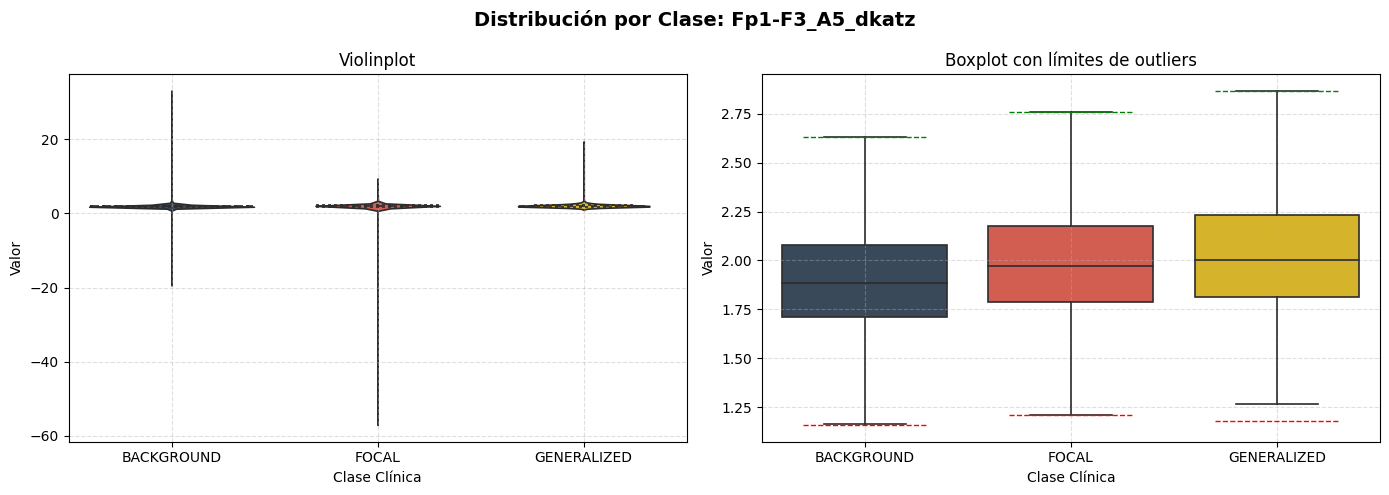

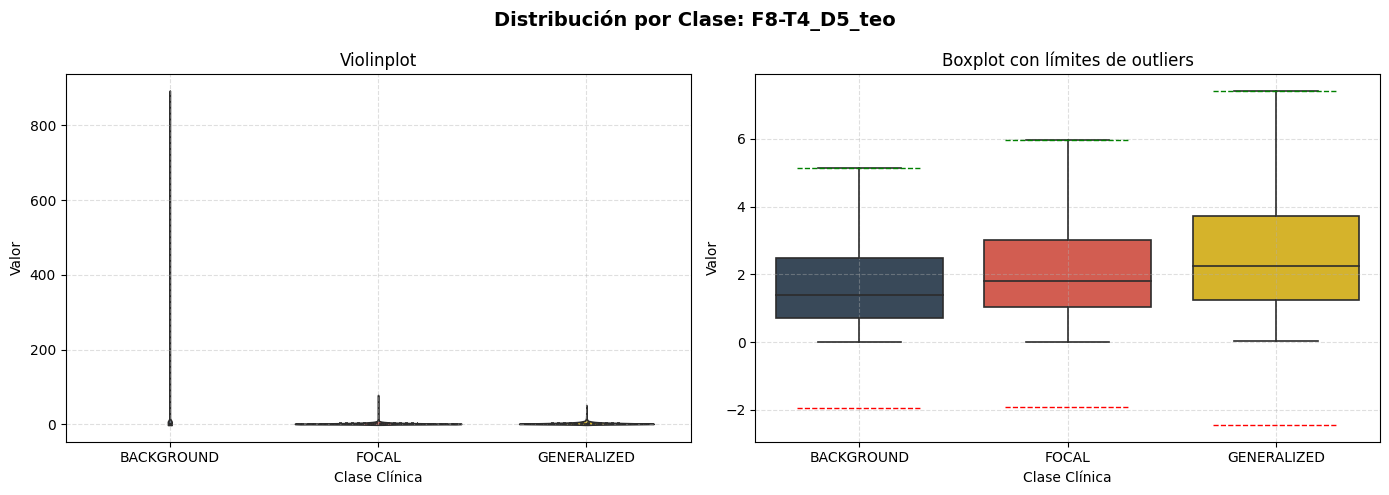

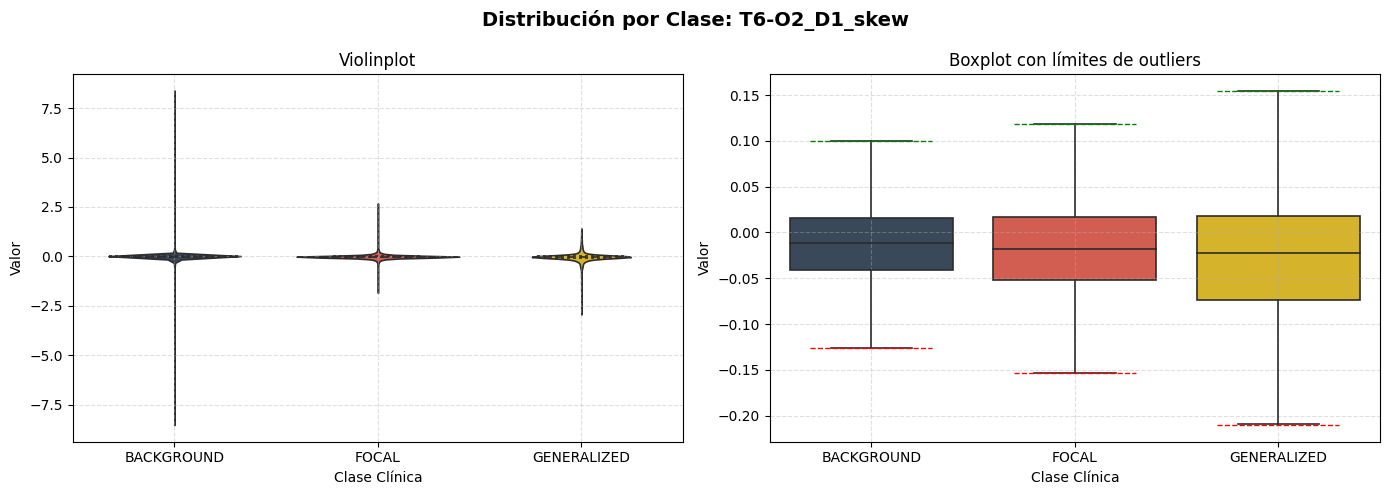

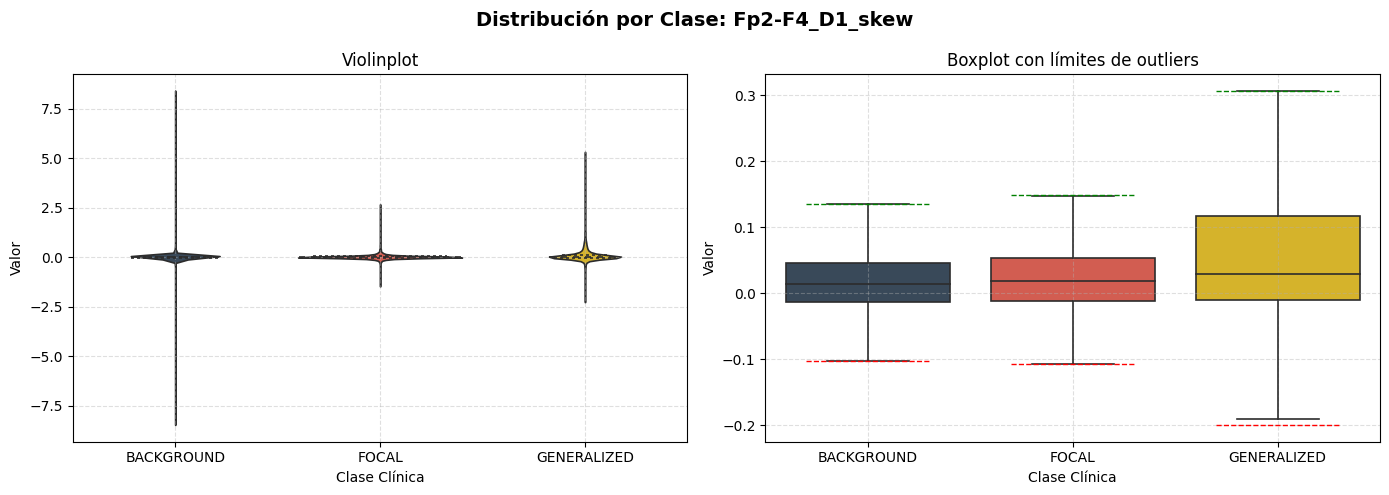

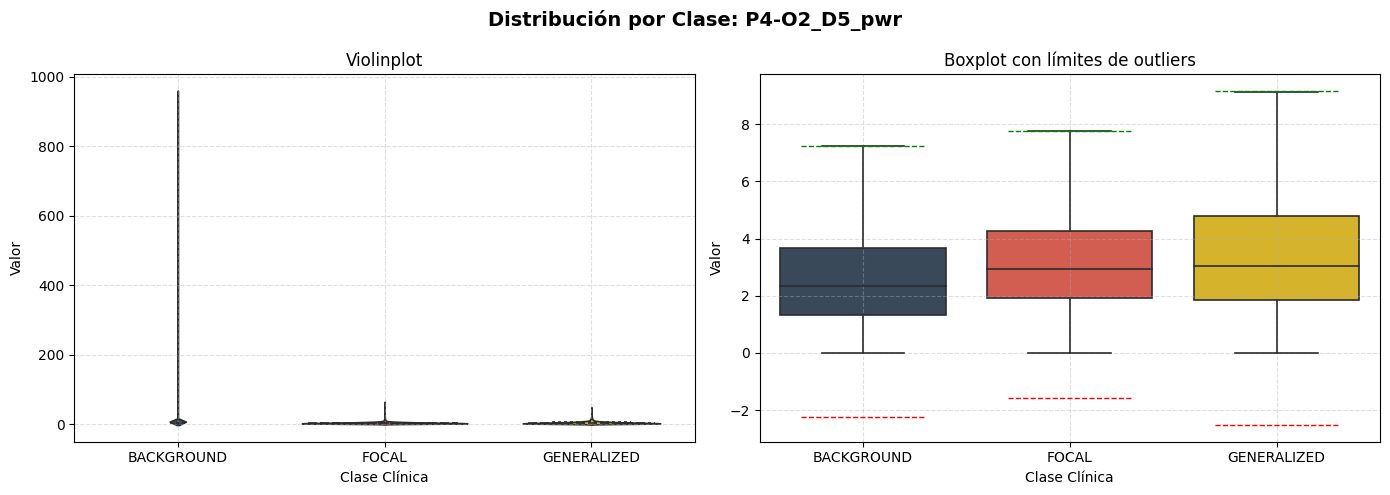

In [49]:
palette = {"BACKGROUND": "#34495e", "FOCAL": "#e74c3c", "GENERALIZED": "#f1c40f"}
orden = ['BACKGROUND', 'FOCAL', 'GENERALIZED']

for feat in df_tabla_top['Feature']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Distribución por Clase: {feat}", fontsize=14, fontweight='bold')

    # --- Violinplot ---
    sns.violinplot(
        data=df,
        x='class',
        y=feat,
        order=orden,
        palette=palette,
        inner='quartile',
        linewidth=1.2,
        ax=axes[0]
    )
    axes[0].set_title("Violinplot", fontsize=12)
    axes[0].set_xlabel("Clase Clínica")
    axes[0].set_ylabel("Valor")
    axes[0].grid(True, linestyle="--", alpha=0.4)

    # --- Boxplot por clase ---
    sns.boxplot(
        data=df,
        x='class',
        y=feat,
        order=orden,
        palette=palette,
        showfliers=False,
        linewidth=1.2,
        ax=axes[1]
    )

    # Líneas de referencia por clase
    for i, clase in enumerate(orden):
        serie_clase = df.loc[df['class'] == clase, feat].dropna()
        Q1 = serie_clase.quantile(0.25)
        Q3 = serie_clase.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        axes[1].hlines(lower, i - 0.3, i + 0.3, colors='red', linestyles='--', linewidth=1)
        axes[1].hlines(upper, i - 0.3, i + 0.3, colors='green', linestyles='--', linewidth=1)

    axes[1].set_title("Boxplot con límites de outliers", fontsize=12)
    axes[1].set_xlabel("Clase Clínica")
    axes[1].set_ylabel("Valor")
    axes[1].grid(True, linestyle="--", alpha=0.4)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)

    plt.tight_layout()
    plt.show()

### Interpretación general de las características más relevantes

```{admonition} Lectura general de los gráficos
:class: note
```

El análisis visual mediante violinplots y boxplots permite examinar la distribución de varias características radiómicas entre las clases clínicas BACKGROUND, FOCAL y GENERALIZED. Aunque las figuras mostradas corresponden únicamente a un subconjunto del conjunto total de variables analizadas, los patrones observados son representativos del comportamiento general identificado en las características más relevantes del modelo.

---

En primer lugar, algunas variables muestran una clara capacidad de discriminación entre clases. La característica *P4-O2\_A5\_ll* (Line Length en el canal parieto-occipital derecho) destaca particularmente, ya que presenta distribuciones claramente separadas entre BACKGROUND y los estados de crisis. En el violinplot se observa que BACKGROUND está fuertemente concentrado en valores bajos, mientras que FOCAL y GENERALIZED presentan distribuciones más amplias y desplazadas hacia valores mayores. El boxplot confirma esta tendencia, mostrando medianas significativamente más altas durante las crisis. Este comportamiento es consistente con la interpretación fisiológica de la métrica, ya que la longitud de línea aumenta cuando la señal EEG presenta mayor amplitud y complejidad durante eventos epilépticos.

De forma similar, la característica *F8-T4\_D5\_teo* (operador de energía de Teager) muestra un patrón progresivo en el que las medianas aumentan desde BACKGROUND hacia FOCAL y posteriormente hacia GENERALIZED. Esta tendencia sugiere un incremento gradual en la energía instantánea de la señal EEG a medida que aumenta la severidad o extensión de la actividad epiléptica, lo que coincide con su relevancia observada en los análisis estadísticos previos.

---

Otras variables presentan una capacidad de discriminación moderada. Por ejemplo, *P4-O2\_D1\_kurt* (kurtosis) muestra valores de mediana más altos en la clase GENERALIZED en comparación con BACKGROUND y FOCAL. Esto sugiere que durante crisis generalizadas la señal EEG presenta distribuciones más leptocúrticas, es decir, con mayor concentración de valores extremos o picos pronunciados. De manera similar, variables relacionadas con potencia espectral, como *Fp1-F7\_D4\_pwr*, muestran mayor dispersión y ligeros incrementos en las medianas para la clase GENERALIZED, lo cual podría reflejar incrementos en la actividad espectral durante ciertos estados epilépticos.

Sin embargo, varias características presentan una separación muy limitada entre clases. Este es el caso de múltiples variables basadas en asimetría (*skewness*), como *P4-O2\_D1\_skew*, *C4-P4\_D1\_skew* y *T6-O2\_D1\_skew*. En estos casos, tanto los violinplots como los boxplots muestran distribuciones fuertemente concentradas alrededor de cero y prácticamente superpuestas entre las tres clases clínicas. Este comportamiento confirma los resultados estadísticos obtenidos previamente, donde dichas características presentaron tamaños de efecto muy pequeños y escasa capacidad discriminativa.

---

Otro aspecto relevante observado en múltiples gráficos es la presencia de valores atípicos extremadamente grandes, particularmente en la clase BACKGROUND. En algunos casos, como en *Fp2-F4\_D3\_dkatz* o *T4-T6\_D5\_dkatz*, estos valores extremos generan colas muy largas en los violinplots que dificultan la interpretación visual de las distribuciones principales. La presencia de estos outliers puede deberse a artefactos en la señal, errores de procesamiento o propiedades matemáticas de ciertas métricas que amplifican fluctuaciones locales de la señal. En estos casos, los boxplots resultan más informativos al mostrar la distribución central de los datos sin que los valores extremos dominen completamente la visualización.

Asimismo, algunas variables relacionadas con la dimensión fractal presentan comportamientos heterogéneos. Mientras que ciertas características como *Fp2-F8\_A5\_dkatz* muestran valores ligeramente mayores en la clase GENERALIZED, otras como *T4-T6\_D5\_dkatz* presentan medianas y rangos intercuartílicos muy similares entre las tres clases, lo cual indica una capacidad discriminativa prácticamente nula.

---

```{admonition} Síntesis de los patrones observados
:class: important
```

En conjunto, el análisis visual de las distribuciones permite identificar tres patrones principales entre las características analizadas. Un primer grupo está compuesto por variables con clara separación entre clases, como *P4-O2\_A5\_ll* y *F8-T4\_D5\_teo*, las cuales muestran diferencias consistentes en medianas y dispersión entre los estados clínicos. Un segundo grupo presenta una discriminación moderada, donde las diferencias entre clases son visibles pero menos pronunciadas. Finalmente, un tercer grupo incluye características con distribuciones prácticamente superpuestas entre clases, particularmente aquellas basadas en medidas de asimetría.

Estos resultados sugieren que, aunque algunas características individuales presentan capacidad discriminativa limitada, la combinación de múltiples variables podría capturar patrones complejos asociados a la actividad epiléptica. Por lo tanto, estos hallazgos respaldan la necesidad de emplear enfoques multivariados en etapas posteriores del modelado, donde algoritmos de aprendizaje automático puedan explotar la información conjunta de las características más relevantes.

```{admonition} Conclusión del análisis
:class: important
```

En conjunto, los resultados indican que **todas las características presentan diferencias estadísticamente significativas entre las clases**, aunque **la magnitud de dichas diferencias es generalmente pequeña**.

Esto sugiere que la discriminación entre tipos de señal EEG **no depende de una única característica dominante**, sino de la **combinación multivariada de múltiples descriptores espectrales, estadísticos y de complejidad**.

Por lo tanto, estas características constituyen **un conjunto de variables potencialmente informativas que pueden ser explotadas conjuntamente en modelos de clasificación automática**, con el objetivo de mejorar la capacidad de discriminación entre:

- actividad de fondo (**BACKGROUND**)  
- epilepsia focal (**FOCA**)  
- epilepsia generalizada (**GENERALIZADA**)

## 2.4 Análisis estructural del espacio de características mediante reducción de dimensionalidad

### 2.4.1 Técnicas de reducción de dimensionalidad a utilizar

```{admonition} Contexto del análisis
:class: note

El conjunto de datos utilizado en este proyecto contiene millones de segmentos EEG descritos mediante múltiples características numéricas. Aunque en este estudio se seleccionaron únicamente **15 features estadísticamente relevantes**, el espacio de características sigue siendo difícil de interpretar directamente debido a la naturaleza multivariada de los datos.

Las técnicas de **reducción de dimensionalidad** permiten proyectar datos de alta dimensión en espacios de menor dimensión (generalmente 2D o 3D), preservando en la medida de lo posible la estructura geométrica de los datos. Esto facilita:

- visualizar patrones estructurales en el dataset
- detectar posibles agrupamientos naturales
- analizar separabilidad entre clases
- comprender relaciones no evidentes entre variables
```

```{admonition} Métodos utilizados
:class: tip

En este caso se utilizarán dos métodos principales:

- **Principal Component Analysis (PCA)**
- **Uniform Manifold Approximation and Projection (UMAP)**

Cada uno de estos métodos captura diferentes propiedades de la estructura del espacio de características.
```

---

#### 2.4.1.1 Principal Component Analysis (PCA)

```{admonition} Definición
:class: note

El **Análisis de Componentes Principales (PCA)** es una técnica clásica de reducción de dimensionalidad basada en transformaciones lineales. Su objetivo es encontrar nuevas variables ortogonales denominadas **componentes principales**, que maximizan la varianza de los datos proyectados.
```

Formalmente, PCA busca vectores de dirección $w$ que maximicen la varianza de los datos proyectados:

$$
\max_w \; Var(Xw)
$$

sujeto a la restricción:

$$
||w|| = 1
$$

Esto conduce al problema de autovalores de la **matriz de covarianza**:

$$
\Sigma = \frac{1}{n} X^T X
$$

donde los **autovectores** de $\Sigma$ corresponden a las direcciones principales de variación de los datos.

Las proyecciones se obtienen mediante:

$$
Z = XW
$$

donde:

- $X$ es la matriz de datos estandarizados
- $W$ contiene los autovectores asociados a los mayores autovalores
- $Z$ representa los datos proyectados en el nuevo espacio reducido

### Interpretación

```{admonition} Interpretación
:class: tip

Las primeras componentes principales capturan la mayor parte de la variabilidad presente en el dataset. En el contexto de señales EEG, esto permite identificar **direcciones dominantes de variación en las características derivadas de los canales cerebrales**.
```

### Limitaciones

```{admonition} Limitación del método
:class: warning

PCA es un método **lineal**, lo que implica que solo puede capturar relaciones lineales entre variables. Sin embargo, la dinámica de señales EEG suele presentar **estructuras altamente no lineales**, por lo que PCA puede no ser suficiente para revelar la verdadera geometría de los datos.

Por esta razón se incorpora **UMAP** como método no lineal.
```

---

#### 2.4.1.2 Uniform Manifold Approximation and Projection (UMAP)

```{admonition} Descripción del método
:class: note

UMAP es un algoritmo moderno de reducción de dimensionalidad basado en principios de **geometría diferencial y teoría de grafos**. Su objetivo es preservar la **estructura local del espacio de datos**, asumiendo que los datos de alta dimensión se encuentran distribuidos sobre una **variedad (manifold) de menor dimensión**.

El algoritmo se desarrolla en dos etapas principales.
```

### Construcción del grafo de vecindad

Primero se construye un grafo ponderado donde cada punto se conecta con sus **k vecinos más cercanos**. Las probabilidades de conexión se calculan mediante una función de decaimiento exponencial:

$$
p_{ij} = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)
$$

donde:

- $d(x_i, x_j)$ es la distancia entre puntos
- $\rho_i$ ajusta la distancia mínima local
- $\sigma_i$ controla la escala local del vecindario

### Optimización en baja dimensión

Posteriormente se busca una representación de baja dimensión que preserve estas relaciones probabilísticas minimizando la divergencia entre grafos:

$$
C = \sum_{i \neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

donde $q_{ij}$ representa las probabilidades en el espacio reducido.

### Interpretación

```{admonition} Interpretación
:class: tip

UMAP es particularmente eficaz para:

- preservar **estructuras locales**
- revelar **clusters de alta densidad**
- mantener separaciones naturales entre grupos

En el contexto de EEG, esto permite explorar si **los distintos tipos de crisis generan agrupamientos naturales en el espacio de características**.
```

---

## Justificación del uso combinado de PCA y UMAP

```{admonition} Justificación metodológica
:class: important

Cada uno de los métodos utilizados captura distintos aspectos de la geometría del espacio de características:
```

| Método | Tipo | Qué preserva |
|------|------|------|
| PCA | Lineal | Varianza global |
| UMAP | No lineal | Estructura local |

```{admonition} Interpretación conjunta
:class: tip

El uso combinado de estas técnicas permite obtener una visión más completa de la organización del espacio de datos, permitiendo analizar simultáneamente:

- variabilidad global de las características
- agrupamientos locales entre tipos de crisis
- posibles transiciones estructurales entre estados neuronales

Esta estrategia proporciona una exploración más precisa del espacio de características antes de aplicar modelos de aprendizaje automático.
```

### 2.4.2 Preparación de las features

Antes de aplicar las **técnicas de reducción de dimensionalidad**, es necesario preparar adecuadamente el conjunto de datos. En particular, se requiere construir una **matriz de características** consistente que contenga **únicamente** las variables seleccionadas previamente como relevantes para la discriminación entre tipos de crisis epilépticas.

En la sección anterior se identificaron **15** características mediante análisis estadísticos no paramétricos basados en la prueba de **Kruskal–Wallis** y comparaciones **post-hoc** entre los distintos tipos de crisis. Estas variables constituyen el subconjunto de features que se utilizará para analizar la estructura del espacio de características mediante técnicas de proyección en baja dimensión.

In [2]:
features_top15 = [
    "P4-O2_A5_ll",
    "P4-O2_D1_kurt",
    "Fp1-F7_D4_pwr",
    "T4-T6_D5_dkatz",
    "Fp2-F4_D3_dkatz",
    "P4-O2_D1_skew",
    "C4-P4_D1_skew",
    "Fp2-F8_A5_dkatz",
    "P3-O1_D1_ll",
    "Fp2-F4_D4_teo",
    "Fp1-F3_A5_dkatz",
    "F8-T4_D5_teo",
    "T6-O2_D1_skew",
    "Fp2-F4_D1_skew",
    "P4-O2_D5_pwr"
]

In [3]:
from pathlib import Path
import pandas as pd

PARQUET_PATH = "C:/Users/USER/Desktop/EDA/04_TUSZ_Features_ML/version=v1_raw_labels"

all_files = list(Path(PARQUET_PATH).rglob("*.parquet"))

Dado que el conjunto de datos de características se encuentra almacenado en múltiples archivos en formato parquet, correspondientes a diferentes segmentos de señales EEG, se procede a identificar todos los archivos disponibles dentro del directorio correspondiente.

Posteriormente, cada archivo es leído y filtrado para conservar únicamente las 15 features seleccionadas junto con la variable de etiqueta (label), que indica el tipo de crisis asociado a cada segmento EEG.

In [4]:
dfs = []

for f in all_files:
    
    df = pd.read_parquet(f)

    df = df[features_top15 + ["label"]]  

    dfs.append(df)

df_features = pd.concat(dfs, ignore_index=True)

print("Shape del dataset final:", df_features.shape)

Shape del dataset final: (1510532, 16)


In [11]:
LABEL_MAPPING = {
    'bckg': 'BACKGROUND',
    'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
    'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED',
    'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
}

df_features["class"] = df_features["label"].map(
    lambda x: LABEL_MAPPING.get(x, "BACKGROUND")
)

In [12]:
print("Distribución de clases agrupadas:")
print(df_features["class"].value_counts())

Distribución de clases agrupadas:
class
BACKGROUND     1246253
FOCAL           168568
GENERALIZED      95711
Name: count, dtype: int64


```{admonition} Clases analizadas
:class: note
```

Es importante recordar que en este proyecto las crisis se **clasificaron** en **3** clases principales:

- Background
- Focal
- Generalized

Una vez cargados los archivos individuales, estos son concatenados para construir un único conjunto de datos consolidado.

El dataset resultante contiene **más de 1.5 millones de segmentos EEG**, cada uno descrito por las **15** características seleccionadas y su correspondiente **etiqueta de tipo de crisis**. Este volumen de datos proporciona una base **suficientemente representativa** para explorar la estructura del espacio de características mediante técnicas de **reducción de dimensionalidad**.

Para facilitar el análisis posterior, se separan las variables predictoras y la variable objetivo.

La **matriz X contiene exclusivamente las características seleccionadas, mientras que el vector Y contiene las etiquetas asociadas al tipo de crisis epiléptica**.

In [10]:
X = df_features[features_top15]
y = df_features["class"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (1510532, 15)
Shape de y: (1510532,)


<!-- Antes de aplicar técnicas de reducción de dimensionalidad, es **fundamental** verificar la calidad de los datos. -->

En particular, se revisa la **presencia de valores faltantes (NaN**) y **valores infinitos** dentro de las características seleccionadas. Este paso es crítico, ya que algoritmos como **PCA y UMAP** requieren matrices numéricas bien definidas y pueden fallar o producir resultados inestables si existen valores inválidos.

In [31]:
print("NaN por feature:")

print(X.isna().sum())

NaN por feature:
P4-O2_A5_ll        0
P4-O2_D1_kurt      0
Fp1-F7_D4_pwr      0
T4-T6_D5_dkatz     0
Fp2-F4_D3_dkatz    0
P4-O2_D1_skew      0
C4-P4_D1_skew      0
Fp2-F8_A5_dkatz    0
P3-O1_D1_ll        0
Fp2-F4_D4_teo      0
Fp1-F3_A5_dkatz    0
F8-T4_D5_teo       0
T6-O2_D1_skew      0
Fp2-F4_D1_skew     0
P4-O2_D5_pwr       0
dtype: int64


In [32]:
import numpy as np

print("Valores infinitos:", np.isinf(X).sum().sum())

Valores infinitos: 0


Es evidente entonces, que **no** hay presencia de **valores faltantes (Nan)** ni de **valores infinitos** en el conjunto de variables seleccionadas.

Posteriormente, las características son **estandarizadas** utilizando **StandardScaler**, lo cual **transforma cada variable para que tenga media cero y desviación estándar unitaria**.

Este paso es especialmente importante en técnicas como **PCA**, que son **sensibles a la escala de las variables**. La estandarización asegura que todas las características contribuyan de manera **comparable** al análisis, evitando que variables con mayor magnitud dominen la proyección del espacio de características.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape final:", X_scaled.shape)

Shape final: (1510532, 15)


### 2.4.3 Proyección PCA

A continuación se calcula la **proyección PCA** utilizando las features estandarizadas del dataset.

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Shape PCA:", X_pca.shape)

Shape PCA: (1510532, 2)


In [29]:
print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza acumulada:")
print(pca.explained_variance_ratio_.sum())

Varianza explicada por componente:
[0.11198491 0.09371307]
Varianza acumulada:
0.20569798


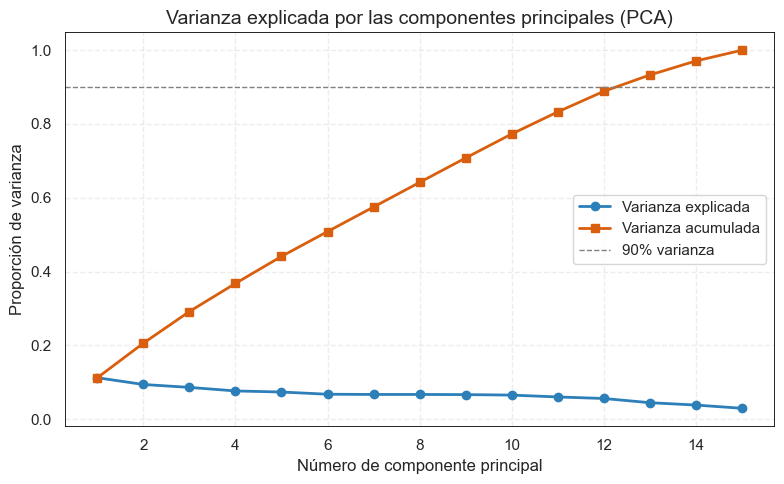

In [33]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

components = np.arange(1, len(explained_var)+1)

plt.figure(figsize=(8,5))

ax = plt.gca()

plt.plot(
    components,
    explained_var,
    marker="o",
    linewidth=2,
    color="#2c7fb8",
    label="Varianza explicada"
)

plt.plot(
    components,
    cum_var,
    marker="s",
    linewidth=2,
    color="#d95f0e",
    label="Varianza acumulada"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    color="gray",
    linewidth=1,
    label="90% varianza"
)

plt.xlabel("Número de componente principal")
plt.ylabel("Proporción de varianza")
plt.title("Varianza explicada por las componentes principales (PCA)", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.35)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.legend(frameon=True)

plt.tight_layout()
plt.show()

### Varianza explicada por las componentes principales

```{admonition} Resultado principal del PCA
:class: important
```

El análisis de PCA muestra que la primera componente principal explica aproximadamente **11.2% de la varianza total**, mientras que la segunda componente explica cerca de **9.4%**. En conjunto, las dos primeras componentes capturan alrededor de **20.6% de la variabilidad presente en el espacio de características**.

---

Este resultado sugiere que la estructura de los datos no está dominada por unas pocas direcciones de variación, sino que la información relevante se encuentra distribuida a lo largo de múltiples dimensiones. Este comportamiento es esperable en datasets derivados de señales fisiológicas complejas, como el EEG, donde múltiples procesos neuronales contribuyen simultáneamente a las características extraídas.

En consecuencia, aunque la proyección en dos dimensiones permite visualizar parcialmente la estructura del espacio de características, es probable que una parte significativa de la variabilidad permanezca distribuida en componentes adicionales no representadas en esta visualización.

---

El **gráfico de varianza explicada** permite observar esta distribución de forma más clara. En él se aprecia que la proporción de varianza capturada por cada componente disminuye de manera gradual, sin presentar un **punto de “codo” (elbow)** pronunciado que indique la presencia de unas pocas direcciones dominantes. Asimismo, la curva de **varianza acumulada** muestra que es necesario incorporar un número considerable de componentes principales para capturar la mayor parte de la variabilidad del dataset.

---

```{admonition} Interpretación
:class: tip
```

Este comportamiento refuerza la idea de que la estructura del espacio de características es intrínsecamente **multidimensional**, lo que justifica posteriormente el uso de técnicas de reducción de dimensionalidad no lineales como **UMAP** para explorar patrones más complejos en los datos.

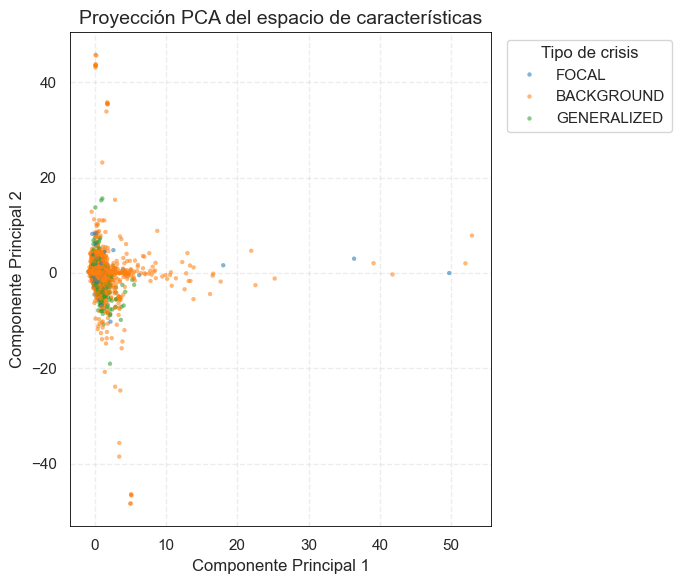

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

df_pca = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "class": y
})

df_sample = df_pca.sample(50000, random_state=42)

plt.figure(figsize=(7,6))

ax = sns.scatterplot(
    data=df_sample,
    x="PC1",
    y="PC2",
    hue="class",
    palette="tab10",
    alpha=0.55,
    s=8,
    edgecolor=None
)

plt.title("Proyección PCA del espacio de características", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.grid(True, linestyle="--", alpha=0.35)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.legend(
    title="Tipo de crisis",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plt.show()

### Análisis visual de la proyección PCA

```{admonition} Lectura del plano PCA
:class: note
```

La proyección de los datos en las dos primeras componentes principales permite explorar la organización global del espacio de características derivadas de las señales EEG.

---

En la visualización se observa que la mayor densidad de puntos se concentra cerca del origen del plano PCA, lo que indica que una gran proporción de los segmentos EEG presentan valores similares en las combinaciones lineales de características capturadas por las dos primeras componentes. Este comportamiento sugiere que muchas observaciones comparten patrones estadísticos relativamente cercanos en el espacio de características.

Asimismo, se observa la presencia de algunos puntos alejados del centro de la distribución, lo que indica la existencia de observaciones con valores extremos en ciertas combinaciones de características. Estos puntos pueden corresponder a segmentos EEG con dinámicas particulares o a configuraciones específicas de actividad cerebral.

---

En cuanto a la distribución por tipo de crisis, no se aprecia una separación clara entre clases en el espacio definido por las dos primeras componentes principales. Las tres categorías clínicas consideradas **BACKGROUND, FOCAL y GENERALIZED** aparecen ampliamente solapadas en la proyección, lo que sugiere que las diferencias entre clases no se explican únicamente mediante combinaciones lineales de las características seleccionadas.

---

```{admonition} Implicación metodológica
:class: important
```

Este resultado es consistente con la naturaleza compleja de las señales EEG, donde las diferencias entre patrones neuronales suelen manifestarse mediante **relaciones no lineales entre variables**. Por esta razón, resulta pertinente aplicar métodos de reducción de dimensionalidad no lineales como **UMAP** que permiten capturar estructuras geométricas más complejas en el espacio de datos.

### 2.4.4 Proyección UMAP

Dado que el conjunto de datos completo contiene más de **1.5 millones de segmentos EEG**, aplicar directamente técnicas de proyección no lineal sobre todo el dataset se vuelve muy costoso computacionalmente. Por esta razón, se utiliza una **muestra representativa de 200 000 observaciones**, preservando la distribución original de las clases mediante un **muestreo estratificado**.

In [14]:
import pandas as pd

df_model = X.copy()
df_model["class"] = y

Para construir esta muestra, primero se combinan las variables predictoras con la etiqueta de clase correspondiente. Posteriormente, se calcula el número de observaciones que deben seleccionarse para cada categoría clínica en función de su proporción en el dataset original. Este procedimiento asegura que la muestra mantenga la **misma estructura de clases** que los datos completos.

In [16]:
sample_size = 200000

class_counts = df_model["class"].value_counts(normalize=True)

samples_per_class = (class_counts * sample_size).round().astype(int)

diff = sample_size - samples_per_class.sum()

if diff != 0:
    largest_class = samples_per_class.idxmax()
    samples_per_class[largest_class] += diff

print("Muestras por clase:")
print(samples_per_class)
print("Total:", samples_per_class.sum())

Muestras por clase:
class
BACKGROUND     165009
FOCAL           22319
GENERALIZED     12672
Name: proportion, dtype: int64
Total: 200000


La muestra obtenida contiene exactamente **200 000 segmentos EEG**, manteniendo proporciones similares entre las tres categorías clínicas consideradas: **BACKGROUND**, **FOCAL** y **GENERALIZED**. Este subconjunto conserva la estructura estadística del dataset original y es a su vez, lo suficientemente grande para explorar la organización del espacio de características mediante técnicas de reducción de dimensionalidad.

In [17]:
dfs = []

for c, n in samples_per_class.items():
    dfs.append(
        df_model[df_model["class"] == c].sample(n=n, random_state=42)
    )

df_sample = pd.concat(dfs, ignore_index=True)

print("Shape muestra:", df_sample.shape)
print("\nDistribución de clases en la muestra:")
print(df_sample["class"].value_counts())

Shape muestra: (200000, 16)

Distribución de clases en la muestra:
class
BACKGROUND     165009
FOCAL           22319
GENERALIZED     12672
Name: count, dtype: int64


In [19]:
X_sample = df_sample[features_top15]
y_sample = df_sample["class"]

Antes de aplicar UMAP, las características son **estandarizadas** utilizando `StandardScaler`. Este paso transforma cada variable para que tenga media cero y desviación estándar unitaria, evitando que diferencias en escala entre las features dominen la construcción del espacio proyectado.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sample_scaled = scaler.fit_transform(X_sample)

print("Shape escalado:", X_sample_scaled.shape)

Shape escalado: (200000, 15)


Una vez estandarizadas las características, se aplica el algoritmo **UMAP** para proyectar los datos en un espacio bidimensional.

En este análisis se utilizan los siguientes hiperparámetros:

- **n_neighbors = 30**, que controla el tamaño del vecindario local considerado
- **min_dist = 0.1**, que regula qué tan compactos pueden ser los clusters en el espacio proyectado
- **metric = euclidean**, utilizada para medir distancias entre observaciones

In [55]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_scaled)

print("Shape UMAP:", X_umap.shape)

C:\Users\USER\anaconda3\envs\EEG_EDA_ML\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape UMAP: (200000, 2)


In [56]:
df_umap = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)

df_umap["class"] = y_sample.values

print(df_umap.head())

       UMAP1     UMAP2       class
0   6.621403  1.884185  BACKGROUND
1  10.874754  2.479000  BACKGROUND
2  10.732440  3.820931  BACKGROUND
3   3.375502  6.730151  BACKGROUND
4   6.108049  4.604668  BACKGROUND


La proyección resultante permite visualizar la organización del espacio de características derivadas de los segmentos EEG. Cada punto en la figura representa un segmento de señal descrito por las **15 características seleccionadas previamente**, mientras que el color indica la categoría clínica correspondiente.

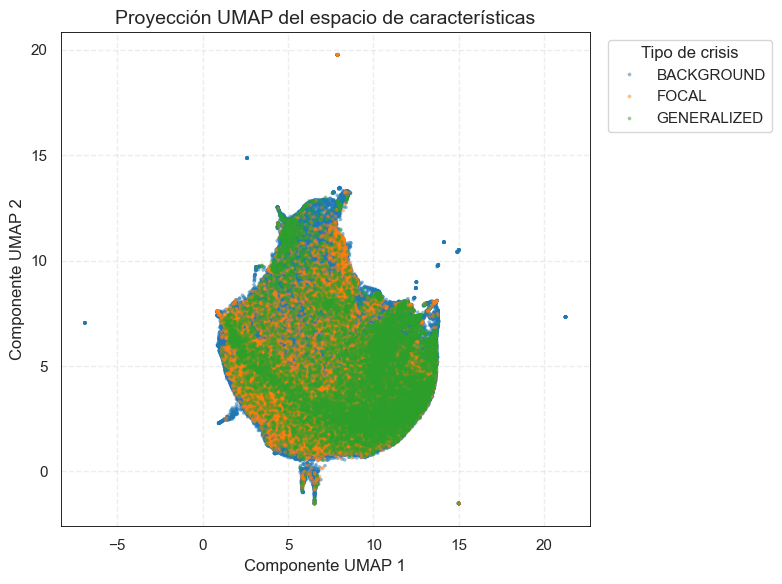

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))

ax = sns.scatterplot(
    data=df_umap,
    x="UMAP1",
    y="UMAP2",
    hue="class",
    palette="tab10",
    alpha=0.5,
    s=7,
    linewidth=0
)

plt.title("Proyección UMAP del espacio de características", fontsize=14)
plt.xlabel("Componente UMAP 1")
plt.ylabel("Componente UMAP 2")

plt.grid(True, linestyle="--", alpha=0.35)

plt.legend(
    title="Tipo de crisis",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=True
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

### Análisis visual de la proyección UMAP

La proyección UMAP revela la estructura global del espacio de características derivado de las señales EEG. En la visualización se observa una región central de alta densidad donde se concentra la mayoría de las observaciones, lo que indica que muchos segmentos EEG comparten configuraciones similares de las características analizadas.

---

```{admonition} Estructura geométrica del espacio de datos
:class: tip
```

A diferencia de la proyección PCA, UMAP permite apreciar **estructuras geométricas más complejas**, generadas por relaciones no lineales entre variables. Sin embargo, incluso utilizando esta técnica no lineal, las tres categorías clínicas consideradas **BACKGROUND, FOCAL y GENERALIZED** presentan un grado considerable de solapamiento en el espacio proyectado.

---

Este comportamiento es consistente con la naturaleza de las señales EEG, donde las diferencias entre patrones cerebrales asociados a distintos tipos de crisis epilépticas no siempre se manifiestan como separaciones claras en el espacio de características. En cambio, estas diferencias pueden reflejarse en **variaciones sutiles dentro de regiones densas del espacio de datos**.

```{admonition} Referencias
:class: note
```

Sharma, M., Dhere, A., & Pachori, R. B. (2020). EEG epileptic seizure detection and classification based on dual-tree complex wavelet transform and machine learning algorithms. *Biomedical Signal Processing and Control*, 57, 101711. https://doi.org/10.1016/j.bspc.2019.101711 [web:116]

Gómez, A., Santillán, A., et al. (2021). *Detección de epilepsia por EEG y desarrollo de un algoritmo localizador del área de inicio de la crisis*. Tesis de maestría, Escuela Colombiana de Ingeniería Julio Garavito, Bogotá, Colombia. Recuperado de https://repositorio.escuelaing.edu.co [web:136]

López, S., et al. (2019). *Correlación de hallazgos electroclínicos y neuroimagenológicos en epilepsia focal en la consulta externa de Neuropediatría del Hospital Infantil Manuel de Jesús Rivera, enero-diciembre 2018-2019*. Tesis, Universidad Nacional Autónoma de Nicaragua, Managua. Recuperado de https://www.minsa.gob.ni [web:146]


